# <center> CAN Log File Analysis, Part 2: Databases, Speed, and Large Files
## <center> SYSE 549: Secure Vehicle and Industrial Networking
## <center><img src="https://www.engr.colostate.edu/~jdaily/Systems-EN-CSU-1-C357.svg" width="400" />
### <center> Instructor: Dr. Jeremy Daily

## Objective
Part 1 converted log files into the candump format and pulled two signals out of a short drive. This notebook asks what happens when CAN logging leaves the classroom: files grow to gigabytes, and the same signals get pulled out again and again.

* Survey the open-source tools that already exist for J1939 work, and what each is good for.
* Put a CAN log into an **SQLite database**, first by hand for two signals, then generally for every SPN in the **SAE J1939 Digital Annex**, which we also convert into a database.
* Measure how fast signals can be pulled out of the database compared with re-reading the text file.
* Stream a 2 GB cross-country log to extract its metadata, trip features and GPS track.

## How this notebook is organized
Everything here is plain Python. The only libraries beyond the standard library are `openpyxl`, to read the Digital Annex spreadsheet, and `matplotlib`, to draw the plots; tables are printed as text. Every function is defined in this notebook, with comments, so there is nothing hidden in helper files. The pattern throughout is hard-code an example first, then generalize: we pull out engine speed by hand before we write a decoder that reads the Digital Annex, and we time one query before we build a benchmark. This is a learning notebook, not production code; where a shortcut makes the idea clearer, we take the shortcut and say so.

## Prerequisites
* The file `candump_kw_drive.txt` in this folder.
* `pip install openpyxl matplotlib`
* The SAE J1939 Digital Annex spreadsheet, `J1939DA JUN2024.xlsx`, in this folder. It is licensed by SAE and is **not** in the git repository (see `.gitignore`); neither is the database we build from it. You may need to change the file with a recent release from SAE if you don't have the JUN2024 version.
* For the last section: `2014_KW_T270_cross_country_can_log.txt` (2 GB, download link in that section). Without it the section runs on the small drive log.

In [10]:
# Run this magic code to get the right prequisites.
%pip install openpyxl matplotlib


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [11]:
import os, sys, csv, json, math, time, struct, sqlite3, calendar
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# A fixed set of colors used for every chart in this notebook (same order every time).
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'

def tidy(ax):
    '''Light-weight chart styling: recessive grid, no top/right spines.'''
    ax.grid(color='#e1e0d9'); ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

def print_table(headers, rows, max_rows=25, floats='{:,.3f}'):
    '''Print a list of rows as an aligned text table. Floats are formatted, None prints as blank.'''
    def fmt(v):
        if v is None: return ''
        if isinstance(v, float): return floats.format(v)
        return str(v)
    cells = [[fmt(v) for v in row] for row in rows[:max_rows]]
    widths = [max(len(str(h)), *(len(c[i]) for c in cells)) if cells else len(str(h)) for i, h in enumerate(headers)]
    print('  '.join(str(h).ljust(w) for h, w in zip(headers, widths)))
    print('  '.join('-' * w for w in widths))
    for c in cells:
        print('  '.join(v.rjust(w) if v.replace(',', '').replace('.', '').replace('-', '').isdigit() else v.ljust(w) for v, w in zip(c, widths)))
    if len(rows) > max_rows:
        print(f'... {len(rows) - max_rows} more rows')

def show(conn, sql, params=(), max_rows=25, floats='{:,.3f}'):
    '''Run a query and print the result as a table, using the column names SQLite reports.'''
    cur = conn.execute(sql, params)
    headers = [d[0] for d in cur.description]
    rows = cur.fetchall()
    print_table(headers, rows, max_rows, floats)
    return rows

print('Python', sys.version.split()[0], '| sqlite', sqlite3.sqlite_version)

Python 3.13.12 | sqlite 3.50.4


# The Landscape: Open-Source J1939 Tools
Before writing our own tools it is worth knowing what already exists, because each project below solved a problem you will meet in this notebook. None of them is a substitute for understanding the protocol, which is the point of building things by hand here, but all of them are worth reading. The table is a snapshot from September 2026.

| Project | What it is | Good for | Notes |
|---|---|---|---|
| **pretty_j1939** (NMFTA) https://github.com/nmfta-repo/pretty_j1939 | Python library and command-line tool that turns candump lines into human-readable J1939 descriptions. Ships `create_j1939db-json`, which converts the SAE Digital Annex spreadsheet into a JSON database. | Decoding any log with names, units and enumerations; reassembling transport-protocol (BAM and RTS/CTS) messages; a reference implementation of the J1939 "not available / error / parameter specific" indicator rules. Its `da_parsers.py` is the hard-won knowledge of how to read every quirk of the Digital Annex's text columns. | MIT. The class file `J1939db.json` follows its JSON layout. The decoder in this notebook borrows its indicator thresholds (`0xFF` = not available, `0xFE` = error, `0xFB` = parameter specific). |
| **canarchy** (hexsecs) https://github.com/hexsecs/canarchy | A newer "stream-first CAN bus toolkit for analysts, security researchers, and AI agents": one CLI with JSON output for capture, decode, replay, compare and reverse engineering, with J1939 (PGN/SPN, TP, DM1, ECU inventory), UDS, DoIP and an MCP server. | Reverse engineering unknown IDs: per-byte entropy, counter and signal candidates with a written rationale, timing anomaly detection using median and MAD instead of mean and standard deviation, and comparing captures against a baseline (rate drop, rate spike, entropy collapse). | GPL-3.0. Works on Python lists rather than a database, so it is comfortable to about 10^5 frames per command; its interface ideas (bounded scans, "estimated" metadata from the head and tail of a huge file, parse-quality warnings) shaped the large-file section below. |
| **TruckDevil** (LittleBlondeDevil) https://github.com/LittleBlondeDevil/TruckDevil | "A framework for interacting with and assessing ECUs that use J1939 for communications on the CAN bus." Modules: `read_messages`, `send_messages`, `ecu_discovery`, `j1939_fuzzer`, plus user-written modules. | Security assessment of a live vehicle or bench ECU: discovering what is on the bus, sending crafted J1939 traffic, fuzzing PGNs. Integrates pretty_j1939 for display. | GPL-3.0, Python 3. Any python-can interface works (SocketCAN, PCAN); the Macchina M2 with the project's firmware is the recommended adapter. |
| **TruckHacking** (organization) https://github.com/TruckHacking | The projects around the **Truck Duck**, a BeagleBone-based heavy-vehicle diagnostic and debugging platform presented at DEF CON 24: `TruckDuckHardware` (schematics and Gerbers), `TruckKernel` (a BeagleBone kernel with J1939 sockets), `py-hv-networks` (Python interfaces to J1939 and J1708), `plc4trucksduck` (a PLC4TRUCKS / J2497 transmitter), `sr-j1708` (a sigrok decoder for J1708). | Getting at the *other* heavy-vehicle networks: J1708/J1587 and the power-line PLC4TRUCKS trailer link, and building your own low-cost interface hardware. The DEF CON paper is a readable introduction to why trucks are a distinct security problem. | Mixed licenses (GPL-3.0, MIT). Much of it is hardware-specific and less active than the software projects above, but the ideas are current. |
| **CAN Logger 3** (Systems Cyber, CSU) https://github.com/SystemsCyber/CAN-Logger-3 | "An open source secure data logging system for heavy vehicle networks": Teensy 3.6 hardware with three CAN channels and J1708, an SD card, and an ATECC608A secure element; firmware, a PyQt desktop app, and an AWS back end. | The problem this notebook keeps circling: capturing every frame and being able to *prove afterwards that the log is intact*. Logs are encrypted with a per-session key, the key is wrapped for the device and the server (envelope encryption), and the data is hashed and signed, so a log file is evidence rather than just a text file. | Compare with the candump text we use here, which anyone can edit with a text editor. `NMFTA CAN Logger 2 on a Navistar A26.bin` in this folder is a binary log from the previous generation. |
| **Linux can-j1939 + can-utils** https://github.com/linux-can/can-utils | The J1939 protocol lives in the mainline Linux kernel (`can-j1939` module): sockets that speak PGNs and addresses instead of raw frames, with transport protocol handled in the kernel. `can-utils` adds `j1939cat`, `j1939acd` (address claiming) and `j1939spy` next to `candump` and `canplayer`. | Writing J1939 applications on a Raspberry Pi without reimplementing TP or address claiming; replaying every log in this folder with `canplayer`. | GPL-2.0 / BSD. The `candump -l` format that all our logs use comes from here. |
| **python-can** https://github.com/hardbyte/python-can | The de facto Python CAN library: one API over SocketCAN, PCAN, Kvaser, Vector, IXXAT and others, with loggers and players for several file formats. | Portable capture scripts on any adapter. | LGPL-3.0. J1939 is not built in; combine with pretty_j1939 or the decoder written in this notebook. The folder `pcan_logger/` next to this notebook holds a C, a Rust and a simulator implementation of a PCAN logger for anyone who wants to compare a compiled logger with a Python one. |

Two patterns stand out. Every decoding project eventually needs the **Digital Annex in a machine-readable form**, which is why we convert it to SQLite below. And every analysis project runs into the **size of real logs**, which is why most of this notebook is about databases and streaming.

# Helpers Used Throughout
Two functions from Part 1, restated here so this notebook stands alone: parse one candump line, and split a 29-bit identifier into its J1939 fields.

In [12]:
def parse_candump(line):
    '''Parse one candump -l line: '(1604007042.461135) can1 18FEBF0B#80067D7D79777B79'
    Returns (timestamp, channel, can_id, data_bytes). Raises ValueError or IndexError on a malformed line.'''
    parts = line.split()
    timestamp = float(parts[0][1:-1])          # strip the parentheses
    channel = parts[1]
    id_text, _, data_text = parts[2].partition('#')
    can_id = int(id_text, 16)
    data = bytes.fromhex(data_text) if data_text and data_text[0] != 'R' else b''   # 'R' = remote frame
    return timestamp, channel, can_id, data

# J1939-21 identifier layout (29 bits): priority(3) | EDP(1) | DP(1) | PF(8) | PS(8) | SA(8)
def get_j1939_from_id(can_id):
    '''Return (priority, PGN, destination address, source address) for a 29-bit CAN ID.'''
    priority = (can_id >> 26) & 0x7
    PF = (can_id >> 16) & 0xFF          # PDU format
    PS = (can_id >> 8) & 0xFF           # PDU specific: destination (PDU1) or group extension (PDU2)
    SA = can_id & 0xFF
    if PF >= 0xF0:                       # PDU2: broadcast; the PS is part of the PGN
        PGN = (can_id >> 8) & 0x3FFFF
        DA = 0xFF
    else:                                # PDU1: peer to peer; the PS is the destination
        PGN = (can_id >> 8) & 0x3FF00
        DA = PS
    return priority, PGN, DA, SA

# Try them on one line from the drive log
t, ch, cid, data = parse_candump('(1604007042.467043) can1 0CF00400#718388001500F0FF')
print(t, ch, hex(cid), data.hex().upper(), get_j1939_from_id(cid))
assert get_j1939_from_id(0x0CF00400) == (3, 61444, 255, 0)     # EEC1 from Engine #1
assert get_j1939_from_id(0x18EA00F9) == (6, 59904, 0, 249)      # Request from diagnostic tool to engine

1604007042.467043 can1 0xcf00400 718388001500F0FF (3, 61444, 255, 0)


# Putting a CAN Log into SQLite, by Hand First
## Why a database?
The candump text format is perfect for *logging*: append-only, human readable, understood by every tool. It is a poor format for *analysis*. To plot engine speed in Part 1 we scanned every line, split it, converted the ID from hex, and threw away 97% of the frames. Do that for ten signals and you scan the file ten times; do it on a 2 GB file and each scan takes minutes.

A database fixes this in two ways. The expensive parsing happens **once**, when the database is built; after that every column is a number. And an **index** lets the database jump straight to the rows that match a query, the way a book's index lets you skip to a page, instead of reading everything.

SQLite is the right database for this job: it is a single file, it is built into Python (`import sqlite3`), and it is fast enough that the whole cross-country log fits comfortably.

## The frames table
One row per frame. The columns are, in this order, the things you would want to search on, then the payload:

| column | type | meaning |
|---|---|---|
| `channel` | TEXT | `can0`, `can1`, ... |
| `sa` | INTEGER | J1939 source address |
| `pgn` | INTEGER | parameter group number |
| `da` | INTEGER | destination address (255 = global) |
| `can_id` | INTEGER | the full 29-bit identifier |
| `timestamp` | REAL | Unix seconds |
| `data` | BLOB | raw payload, 0 to 8 bytes |

An **index** over `(channel, sa, pgn, da, can_id, timestamp)` in that order means a query that fixes the channel, the source address and the PGN walks a small slice of a B-tree. The order matters: a composite index is like a phone book sorted by last name then first name, useless for finding everyone named "Jeremy". We will put that claim to the test later.

Let's build it for the seven-minute drive, with no cleverness at all.

In [13]:
LOG = 'candump_kw_drive.txt'
DB = 'candump_kw_drive.sqlite'

def create_frames_db(db_path):
    '''Create (or wipe and recreate) the database with the frames table.'''
    if os.path.exists(db_path):
        os.remove(db_path)
    conn = sqlite3.connect(db_path)
    # Speed settings for a bulk load: no rollback journal, no fsync per transaction, a big page cache.
    # (We can always rebuild the database from the text file, so durability does not matter here.)
    conn.executescript('''
        PRAGMA journal_mode = OFF;
        PRAGMA synchronous = OFF;
        PRAGMA cache_size = -200000;
        CREATE TABLE frames (
            channel   TEXT    NOT NULL,
            sa        INTEGER NOT NULL,
            pgn       INTEGER NOT NULL,
            da        INTEGER NOT NULL,
            can_id    INTEGER NOT NULL,
            timestamp REAL    NOT NULL,
            data      BLOB
        );
    ''')
    return conn

def load_frames(conn, log_path, batch=50000):
    '''Stream a candump file into the frames table. Returns (frames inserted, bad lines).'''
    rows, n_bad, n = [], 0, 0
    id_cache = {}                                    # can_id -> (sa, pgn, da); there are only a few dozen unique IDs
    with open(log_path) as f:
        for line in f:
            try:
                timestamp, channel, can_id, data = parse_candump(line)
            except (ValueError, IndexError):
                n_bad += 1
                continue
            fields = id_cache.get(can_id)
            if fields is None:
                _, pgn, da, sa = get_j1939_from_id(can_id)
                fields = id_cache[can_id] = (sa, pgn, da)
            rows.append((channel, *fields, can_id, timestamp, data))
            if len(rows) >= batch:                   # executemany in batches is far faster than one execute per row
                conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?)', rows); rows.clear(); n += batch
    conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?)', rows); n += len(rows)
    conn.commit()
    return n, n_bad

t0 = time.perf_counter()
conn = create_frames_db(DB)
n_frames, n_bad = load_frames(conn, LOG)
t_load = time.perf_counter() - t0
t0 = time.perf_counter()
conn.execute('CREATE INDEX idx_frames_keys ON frames (channel, sa, pgn, da, can_id, timestamp)')
conn.commit()
t_index = time.perf_counter() - t0
print(f'{n_frames:,} frames loaded in {t_load:.2f} s ({n_frames/t_load:,.0f} frames/s), {n_bad} bad lines; index built in {t_index:.2f} s')
print(f'text {os.path.getsize(LOG)/1e6:.1f} MB -> database {os.path.getsize(DB)/1e6:.1f} MB')

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'candump_kw_drive.sqlite'

In [4]:
# `show` runs a query and prints the rows; the column names come from SQLite itself
show(conn, "SELECT channel, sa, pgn, da, printf('%08X', can_id) AS id_hex, timestamp, hex(data) AS data FROM frames LIMIT 5", floats='{:.6f}');

channel  sa  pgn    da   id_hex    timestamp          data            
-------  --  -----  ---  --------  -----------------  ----------------
can1     11  65215  255  18FEBF0B  1604007042.461135  80067D7D79777B79
can1     11  65134  255  08FE6E0B  1604007042.461719  8006800640062006
can1      0  61444  255  0CF00400  1604007042.467043  718388001500F0FF
can1      0  61444  255  0CF00400  1604007042.477151  218389001500F0FF
can1     11  65134  255  08FE6E0B  1604007042.481290  6006200640064006


In [5]:
# Who is talking, and how much? GROUP BY replaces the dictionary-counting loop from Part 1.
show(conn, '''
    SELECT sa, pgn, printf('%04X', pgn) AS pgn_hex, COUNT(*) AS frames
    FROM frames GROUP BY sa, pgn ORDER BY frames DESC LIMIT 12''');

sa  pgn    pgn_hex  frames
--  -----  -------  ------
 0  61444  F004      41156
11  65134  FE6E      20436
 0  61443  F003       8231
49  61443  F003       8231
11  65215  FEBF       8175
 0  65248  FEE0       4116
 0  65265  FEF1       4116
 0  65266  FEF2       4116
15  61440  F000       4116
49  61441  F001       4116
49  65264  FEF0       4116
49  65265  FEF1       4116


## Two signals, decoded by hand
Now the hard-coded part. From Part 1 we know exactly where two signals live:

* **SPN 190, Engine Speed**: PGN 61444 (EEC1), bytes 4-5, little-endian, 0.125 rpm per bit, no offset.
* **SPN 84, Wheel-Based Vehicle Speed**: PGN 65265 (CCVS1), bytes 2-3, little-endian, 1/256 km/h per bit, no offset.

We pull the matching frames out of `frames` with the index, decode them in Python with `struct.unpack`, and store the results in a second table, `signals(sa, spn, timestamp, value)`. Its index is `(sa, spn, timestamp)`: on a vehicle the source address barely varies (engine speed always comes from SA 0), so we lead with it and let the SPN split each address's rows into signals.

In [6]:
conn.executescript('''
    CREATE TABLE IF NOT EXISTS signals (
        sa        INTEGER NOT NULL,
        spn       INTEGER NOT NULL,
        timestamp REAL    NOT NULL,
        value     REAL
    );
    CREATE INDEX IF NOT EXISTS idx_signals ON signals (sa, spn, timestamp);
''')

def decode_hardcoded(conn, sa=0):
    '''Decode SPN 190 and SPN 84 from source address `sa` into the signals table, the Part 1 way.'''
    rows = []
    for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=? AND pgn=61444', (sa,)):
        rpm = struct.unpack('<H', data[3:5])[0] * 0.125          # bytes 4-5 -> Python indexes 3:5
        rows.append((sa, 190, timestamp, rpm))
    for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=? AND pgn=65265', (sa,)):
        kph = struct.unpack('<H', data[1:3])[0] / 256             # bytes 2-3 -> indexes 1:3
        rows.append((sa, 84, timestamp, kph))
    conn.execute('DELETE FROM signals WHERE sa=? AND spn IN (190, 84)', (sa,))
    conn.executemany('INSERT INTO signals VALUES (?,?,?,?)', rows)
    conn.commit()
    return len(rows)

print(decode_hardcoded(conn), 'signal values stored')
show(conn, 'SELECT spn, COUNT(*) AS n, MIN(value) AS min, MAX(value) AS max, AVG(value) AS mean FROM signals GROUP BY spn');

45272 signal values stored
spn  n      min      max        mean   
---  -----  -------  ---------  -------
 84   4116    0.000     54.688   22.364
190  41156  568.500  1,791.250  994.610


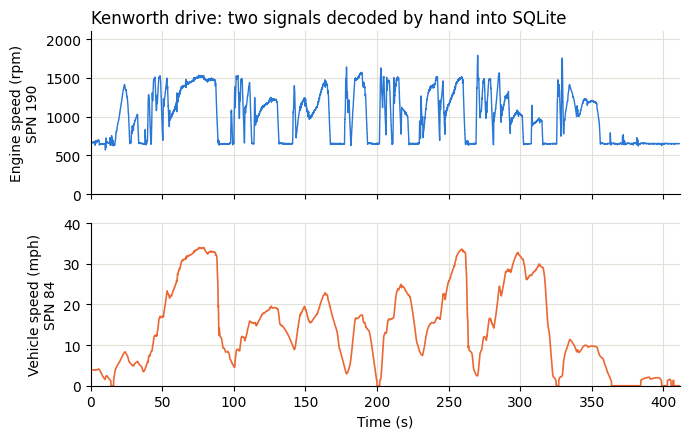

In [7]:
def series(conn, sa, spn):
    '''(timestamps, values) for one signal, as two plain lists.'''
    rows = conn.execute('SELECT timestamp, value FROM signals WHERE sa=? AND spn=? ORDER BY timestamp', (sa, spn)).fetchall()
    return [r[0] for r in rows], [r[1] for r in rows]

def plot_two_signals(conn, sa=0, title=''):
    '''Engine speed and vehicle speed from the signals table, stacked on a shared time axis.
    (Two units, two axes: a dual-axis chart would invite comparing heights that mean nothing.)'''
    t190, rpm = series(conn, sa, 190)
    t84, kph = series(conn, sa, 84)
    t0 = min(t190[0], t84[0])
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 4.5))
    ax1.plot([t - t0 for t in t190], rpm, color=BLUE, linewidth=1); ax1.set_ylabel('Engine speed (rpm)\nSPN 190'); ax1.set_ylim(0, 2100)
    ax2.plot([t - t0 for t in t84], [v * 0.621371 for v in kph], color=ORANGE, linewidth=1.2); ax2.set_ylabel('Vehicle speed (mph)\nSPN 84'); ax2.set_ylim(0, 40)
    ax2.set_xlabel('Time (s)'); ax1.set_title(title, loc='left'); ax1.autoscale(enable=True, axis='x', tight=True)
    tidy(ax1); tidy(ax2); plt.tight_layout()

plot_two_signals(conn, title='Kenworth drive: two signals decoded by hand into SQLite')

That is the whole idea, in about forty lines: parse once into `frames`, decode into `signals`, and from then on every plot is a `SELECT`. The trouble is the phrase *decoded by hand*. We knew the byte positions and scaling for two SPNs. The J1939 Digital Annex defines over thirty thousand. To generalize, we need the Digital Annex itself in a form a program can read.

# The J1939 Digital Annex as a Database
## What the Digital Annex is
SAE J1939 is published in two forms: the standard documents (J1939-71 and friends, prose and tables) and the **Digital Annex** (J1939DA), an Excel workbook that lists every parameter group and suspect parameter with its position, length, scaling, offset, range and description. Anyone decoding J1939 professionally works from the Digital Annex. It is licensed by SAE, which is why the spreadsheet and anything derived from it stay out of the public repository.

The workbook has a dozen sheets; the ones we need are

| Sheet | Contents |
|---|---|
| `SPs & PGs` | one row per (PGN, SPN) pair: ~32 000 rows, 44 columns |
| `Global Source Addresses (B2)` | the preferred source addresses 0-255 (Engine #1 = 0, Brakes = 11, ...) |
| `IG1 Source Addresses (B3)` | additional addresses for on-highway vehicles (industry group 1) |
| `Manufacturer IDs (B10)` | the manufacturer code used in the 64-bit J1939 NAME |
| `SLOTs` | the scaling / limit / offset / transfer-function definitions that SPNs refer to |

Older editions of the Digital Annex describe positions and scaling only as text ("4-5", "0.125 rpm/bit", "2 bytes"), and a converter has to parse every variant; pretty_j1939's `da_parsers.py` is 800 lines of exactly that. The 2024 edition adds machine-friendly columns (`SP Start Bit` as `byte.bit`, `Scale Factor (value only)`, `Offset (value only)`, `Length Minimum (bits)`), which we use here. If you have an older edition, look at how pretty_j1939 does it.

## Reading the spreadsheet
`openpyxl` reads `.xlsx` files. In `read_only` mode it streams rows instead of loading the whole workbook, and `data_only=True` gives the values of formula cells. Every sheet has three title rows above the header, so the header is row 4. We turn each sheet into a list of dictionaries keyed by column name, which is all a spreadsheet really is.

In [8]:
import openpyxl

DA_XLSX = 'J1939DA JUN2024.xlsx'
DA_DB = 'J1939DA.sqlite'

def read_sheet(wb, name, header_row=4):
    '''Return a list of {column name: value} dictionaries for one worksheet.'''
    ws = wb[name]
    rows = ws.iter_rows(min_row=header_row, values_only=True)
    headers = [str(h).replace('\n', ' ').strip() if h is not None else f'col{i}' for i, h in enumerate(next(rows))]
    return [dict(zip(headers, row)) for row in rows]

t0 = time.perf_counter()
wb = openpyxl.load_workbook(DA_XLSX, read_only=True, data_only=True)
print('sheets:', wb.sheetnames)
da = {name: read_sheet(wb, name) for name in ['SPs & PGs', 'Global Source Addresses (B2)', 'IG1 Source Addresses (B3)', 'Manufacturer IDs (B10)', 'SLOTs']}
wb.close()
print(f'read in {time.perf_counter()-t0:.1f} s:', {k: len(v) for k, v in da.items()})
print(list(da['SPs & PGs'][0].keys()))

sheets: ['Documentation', 'Abbreviations', 'Revision Column Definition', 'SAE J1939DA Schema Changes', 'SPs & PGs', 'SLOTs', 'Manufacturer IDs (B10)', 'Global Source Addresses (B2)', 'Global NAME Functions (B11)', 'IG Specific NAME Function (B12)', 'Industry Groups (B1)', 'IG1 Source Addresses (B3)', 'IG2 Source Addresses (B4)', 'IG3 Source Addresses (B5)', 'IG4 Source Addresses (B6)', 'IG5 Source Addresses (B7)', 'Supporting Information (App. D)']


read in 5.1 s: {'SPs & PGs': 32763, 'Global Source Addresses (B2)': 108, 'IG1 Source Addresses (B3)': 74, 'Manufacturer IDs (B10)': 1470, 'SLOTs': 418}
['Revised', 'PG Revised', 'SP Revised', 'SP to PG Map Revised', 'PGN', 'PG Label', 'PG Acronym', 'PG Description', 'PDU Type', 'PGN Page', 'PG Data Length Class', 'PG Data Minimum Length', 'PG Data Length Constraint', 'PG Data Highest Assigned Byte', 'Transmission Rate', 'Default Priority', 'PG Reference', 'SP Position in PG', 'SP Start Bit', 'SPN', 'SP Label', 'SP Description', 'SP Length', 'Scaling', 'Offset', 'Data Range', 'Operational Range', 'Unit', 'SLOT Identifier', 'SLOT Name', 'SP Type', 'SP Reference', 'Scale Factor (value only)', 'Offset (value only)', 'Range Maximum (value only)', 'Length Minimum (bits)', 'Length Maximum (bits)', 'SP Document', 'PG Document', 'SP Created or Modified Date', 'PG Created or Modified Date', 'SP to PG Mapping Created or Modified Date', 'Row PG Content', 'Row SP Content']


In [9]:
# One row, the way the Digital Annex sees engine speed
row190 = next(r for r in da['SPs & PGs'] if r['SPN'] == 190)
for k, v in row190.items():
    if v not in (None, ''):
        print(f'{k:42s} {str(v)[:90]}')

PGN                                        61444
PG Label                                   Electronic Engine Controller 1
PG Acronym                                 EEC1
PG Description                             Engine related parameters
PDU Type                                   PDU2
PGN Page                                   Page 0
PG Data Length Class                       Fixed
PG Data Minimum Length                     8
PG Data Highest Assigned Byte              8
Transmission Rate                          Fixed rate of 10 to 50 ms or engine speed dependent
Default Priority                           3
SP Position in PG                          4-5
SP Start Bit                               4.1
SPN                                        190
SP Label                                   Engine Speed
SP Description                             Actual engine speed which is calculated over a minimum crankshaft angle of 720 degrees div
SP Length                                  2 bytes
S

Note the units: the Digital Annex gives SPN 84 in **km/h at 1/256 km/h per bit**, while the class file `J1939db.json` had already converted it to mph (0.00242723 mph per bit is 1/256 km/h times 0.621371). Both are right; you have to know which one your decoder uses. Also note `SP Start Bit` is a number like `4.1` meaning *byte 4, bit 1* with bytes and bits numbered from 1, the J1939 convention; the LSB of byte 1 is bit position 0 in a little-endian 64-bit view of the payload.

## Schema
Three tables carry the SP/PG information. `pgns` and `spns` each hold one row per definition; `spn_pgn` records which SPN sits where in which PGN, because the same SPN can appear in more than one PGN (169 of them do in this edition), and the position is a property of the pair, not the SPN.

In [10]:
DA_SCHEMA = '''
CREATE TABLE pgns (
    pgn INTEGER PRIMARY KEY, label TEXT, acronym TEXT, description TEXT, pdu_type TEXT,
    length_class TEXT, min_length_bytes INTEGER, transmission_rate TEXT, default_priority INTEGER, document TEXT);
CREATE TABLE spns (
    spn INTEGER PRIMARY KEY, label TEXT, description TEXT, length_bits INTEGER, length_max_bits INTEGER,
    scale REAL, offset REAL, units TEXT, scaling_text TEXT, offset_text TEXT, data_range TEXT, operational_range TEXT,
    slot_id INTEGER, slot_name TEXT, sp_type TEXT, document TEXT);
CREATE TABLE spn_pgn (
    pgn INTEGER NOT NULL, spn INTEGER NOT NULL, position_text TEXT, start_bit INTEGER,
    PRIMARY KEY (pgn, spn));
CREATE INDEX idx_spn_pgn_spn ON spn_pgn (spn);
CREATE TABLE source_addresses (sa INTEGER PRIMARY KEY, name TEXT, notes TEXT, sheet TEXT);
CREATE TABLE manufacturers (id INTEGER PRIMARY KEY, name TEXT, location TEXT);
CREATE TABLE slots (slot_id INTEGER PRIMARY KEY, name TEXT, slot_type TEXT, scaling TEXT, range TEXT, offset TEXT, length TEXT, units TEXT);
'''

def start_bit_from_da(value):
    '''Digital Annex 'SP Start Bit' (e.g. 4.1 = byte 4, bit 1; both 1-based) -> 0-based bit offset in the payload.'''
    if value is None or value == '':
        return None
    byte = int(value)
    bit = int(round((float(value) - byte) * 10))
    return (byte - 1) * 8 + (bit - 1)

assert start_bit_from_da(1.1) == 0 and start_bit_from_da(4.1) == 24 and start_bit_from_da(2.5) == 12

def to_int(x):
    '''int, or None for cells that are blank, 'N/A', or otherwise not a number.'''
    try:
        return int(x)
    except (TypeError, ValueError):
        return None

def to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None

def text(x):
    return None if x is None else str(x).strip()

In [11]:
def build_da_database(da, db_path=DA_DB):
    '''Load the Digital Annex sheets (lists of row dictionaries) into an SQLite database.'''
    if os.path.exists(db_path):
        os.remove(db_path)
    conn = sqlite3.connect(db_path)
    conn.executescript(DA_SCHEMA)

    pgn_rows, spn_rows, map_rows = {}, {}, []
    for row in da['SPs & PGs']:
        pgn, spn = to_int(row['PGN']), to_int(row['SPN'])
        if pgn is not None and pgn not in pgn_rows:
            pgn_rows[pgn] = (pgn, text(row['PG Label']), text(row['PG Acronym']), text(row['PG Description']), text(row['PDU Type']),
                             text(row['PG Data Length Class']), to_int(row['PG Data Minimum Length']), text(row['Transmission Rate']),
                             to_int(row['Default Priority']), text(row['PG Document']))
        if spn is not None and spn not in spn_rows:      # the first definition wins; the DA is consistent within an edition
            spn_rows[spn] = (spn, text(row['SP Label']), text(row['SP Description']), to_int(row['Length Minimum (bits)']),
                             to_int(row['Length Maximum (bits)']), to_float(row['Scale Factor (value only)']), to_float(row['Offset (value only)']),
                             text(row['Unit']), text(row['Scaling']), text(row['Offset']), text(row['Data Range']), text(row['Operational Range']),
                             to_int(row['SLOT Identifier']), text(row['SLOT Name']), text(row['SP Type']), text(row['SP Document']))
        if pgn is not None and spn is not None:
            map_rows.append((pgn, spn, text(row['SP Position in PG']), start_bit_from_da(to_float(row['SP Start Bit']))))

    conn.executemany('INSERT INTO pgns VALUES (?,?,?,?,?,?,?,?,?,?)', pgn_rows.values())
    conn.executemany('INSERT INTO spns VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)', spn_rows.values())
    conn.executemany('INSERT OR IGNORE INTO spn_pgn VALUES (?,?,?,?)', map_rows)

    # Source addresses: the global table, then industry group 1 (on-highway) for addresses the global table leaves open.
    for sheet in ('Global Source Addresses (B2)', 'IG1 Source Addresses (B3)'):
        for row in da[sheet]:
            sa, name, notes = to_int(row['Source Address ID']), text(row['Name']), text(row['Notes'])
            if sa is None:
                continue
            if name and name.lower().startswith('thru'):          # "thru 155 are reserved for ..." describes a range
                end = to_int(name.split()[1]) or sa
                label = name.split(' are ', 1)[-1].capitalize()
                conn.executemany('INSERT OR IGNORE INTO source_addresses VALUES (?,?,?,?)', [(a, label, notes, sheet) for a in range(sa, end + 1)])
            else:
                conn.execute('INSERT OR IGNORE INTO source_addresses VALUES (?,?,?,?)', (sa, name, notes, sheet))
    for row in da['Manufacturer IDs (B10)']:
        if to_int(row['Mfr ID']) is not None:
            conn.execute('INSERT OR IGNORE INTO manufacturers VALUES (?,?,?)', (to_int(row['Mfr ID']), text(row['Manufacturer']), text(row['Location'])))
    for row in da['SLOTs']:
        if to_int(row['SLOT Identifier']) is not None:
            conn.execute('INSERT OR IGNORE INTO slots VALUES (?,?,?,?,?,?,?,?)',
                         (to_int(row['SLOT Identifier']), text(row['SLOT Name']), text(row['SLOT Type']), text(row['Scaling']),
                          text(row['Range']), text(row['Offset']), text(row['Length']), text(row['Unit'])))
    conn.commit()
    counts = {t: conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0] for t in ('pgns', 'spns', 'spn_pgn', 'source_addresses', 'manufacturers', 'slots')}
    return conn, counts

t0 = time.perf_counter()
dadb, counts = build_da_database(da)
print(f'built {DA_DB} in {time.perf_counter()-t0:.1f} s, {os.path.getsize(DA_DB)/1e6:.1f} MB:', counts)

built J1939DA.sqlite in 0.3 s, 14.8 MB: {'pgns': 3103, 'spns': 31469, 'spn_pgn': 15834, 'source_addresses': 256, 'manufacturers': 1470, 'slots': 418}


## Asking the Digital Annex questions
With the tables in place, the questions that used to mean scrolling through a spreadsheet become one-line queries.

In [12]:
# What is in EEC1, and where?
show(dadb, '''
    SELECT m.spn, s.label, m.position_text AS position, m.start_bit, s.length_bits, s.scale, s.offset, s.units
    FROM spn_pgn m JOIN spns s ON s.spn = m.spn
    WHERE m.pgn = 61444 ORDER BY m.start_bit''');

spn   label                                                    position  start_bit  length_bits  scale  offset    units         
----  -------------------------------------------------------  --------  ---------  -----------  -----  --------  --------------
 899  Engine Torque Mode                                            1.1          0            4  1.000     0.000                
4154  Actual Engine - Percent Torque (Fractional)                   1.5          4            4  0.125     0.000  %             
 512  Driver's Demand Engine - Percent Torque                         2          8            8  1.000  -125.000  %             
 513  Actual Engine - Percent Torque                                  3         16            8  1.000  -125.000  %             
 190  Engine Speed                                                  4-5         24           16  0.125     0.000  rpm           
1483  Source Address of Controlling Device for Engine Control         6         40            8  

In [13]:
# Which PGNs carry engine speed? (an SPN can live in more than one parameter group)
show(dadb, 'SELECT m.pgn, p.acronym, p.label, m.position_text FROM spn_pgn m JOIN pgns p USING (pgn) WHERE m.spn = 190')
print()
# Who is source address 11? 49? 249?
show(dadb, 'SELECT sa, name FROM source_addresses WHERE sa IN (0, 11, 15, 49, 85, 249, 255)');

pgn    acronym  label                           position_text
-----  -------  ------------------------------  -------------
61444  EEC1     Electronic Engine Controller 1            4-5

sa   name                                
---  ------------------------------------
  0  Engine #1                           
 11  Brakes - System Controller          
 15  Retarder - Engine                   
 49  Cab Controller - Primary            
 85  Diesel Particulate Filter Controller
249  Off Board Diagnostic-Service Tool #1
255  GLOBAL (All-Any Node)               


In [14]:
# SQLite can open a second database file on the same connection, so one query can join the log against the Digital Annex.
conn.execute('ATTACH DATABASE ? AS da', (DA_DB,))

# Which PGNs in the drive log does the Digital Annex not know? Proprietary PGNs (PropA 61184, PropB 65280-65535)
# have a row in the Digital Annex but no SPNs, so we check for those separately.
unknown = conn.execute('SELECT DISTINCT pgn FROM frames WHERE pgn NOT IN (SELECT pgn FROM da.pgns)').fetchall()
proprietary = conn.execute('SELECT DISTINCT pgn FROM frames WHERE pgn = 61184 OR pgn BETWEEN 65280 AND 65535').fetchall()
n_pgns = conn.execute('SELECT COUNT(DISTINCT pgn) FROM frames').fetchone()[0]
print(f'{n_pgns} distinct PGNs in the log; {len(unknown)} not in the Digital Annex; {len(proprietary)} proprietary')

41 distinct PGNs in the log; 0 not in the Digital Annex; 0 proprietary


In [15]:
# The "who is talking" table from earlier, now with names from the Digital Annex
show(conn, '''
    SELECT f.sa, a.name AS source, f.pgn, printf('%04X', f.pgn) AS pgn_hex, p.acronym, p.label, COUNT(*) AS frames
    FROM frames f
    LEFT JOIN da.source_addresses a ON a.sa = f.sa
    LEFT JOIN da.pgns p ON p.pgn = f.pgn
    GROUP BY f.sa, f.pgn ORDER BY frames DESC''', max_rows=15);

sa  source                      pgn    pgn_hex  acronym  label                             frames
--  --------------------------  -----  -------  -------  --------------------------------  ------
 0  Engine #1                   61444  F004     EEC1     Electronic Engine Controller 1     41156
11  Brakes - System Controller  65134  FE6E     HRW      High Resolution Wheel Speed        20436
 0  Engine #1                   61443  F003     EEC2     Electronic Engine Controller 2      8231
49  Cab Controller - Primary    61443  F003     EEC2     Electronic Engine Controller 2      8231
11  Brakes - System Controller  65215  FEBF     EBC2     Wheel Speed Information             8175
 0  Engine #1                   65248  FEE0     VD       Vehicle Distance                    4116
 0  Engine #1                   65265  FEF1     CCVS1    Cruise Control/Vehicle Speed 1      4116
 0  Engine #1                   65266  FEF2     LFE1     Fuel Economy (Liquid)               4116
15  Retarder - Engin

Every PGN in this drive log is defined in the 2024 Digital Annex, including `FE6E` High Resolution Wheel Speed and `FDA1` Aftertreatment 1 Fuel Control, which look exotic but are standard; the class file `J1939db.json` knew fewer than half of them. Logs from other trucks usually also contain **proprietary** PGNs (PropA 61184, PropB 65280-65535): the Digital Annex has a row for each of those but no SPNs, because the contents belong to the manufacturer. That is the general rule: the Digital Annex describes the standard, and each manufacturer keeps its own annex for the rest.

# Generalizing the Decoder
## From a table row to a value
Every decodable SPN in the Digital Annex is described by four numbers: `start_bit`, `length_bits`, `scale` and `offset`. Decoding is then the same three steps for every one of them:

1. View the payload as one little-endian integer (J1939 byte 1 is the least significant byte), shift right by `start_bit`, mask to `length_bits`. This is the raw value.
2. Check the **indicator bytes**. J1939-71 reserves the top of every field's range: for fields of a byte or more, a most-significant byte of `0xFF` means *not available*, `0xFE` means *error*, `0xFB` means *parameter specific*, `0xFC-0xFD` are reserved. For fields shorter than a byte, all ones means not available and all-ones-minus-one means error. (These thresholds are the ones pretty_j1939 uses; the class `J1939db.json` code in Part 1 skipped this step, which is why a 0xFFFF engine speed would have plotted as 8 191 rpm.)
3. `value = raw * scale + offset`.

Instead of a hand-written line per SPN, the plan for a PGN is now a list of `(spn, start_bit, length, scale, offset)` tuples pulled from the database.

In [16]:
def decode_plan(dadb, pgn):
    '''All decodable SPNs of a PGN as (spn, start_bit, length_bits, scale, offset), from the Digital Annex database.
    SPNs without a start bit or a fixed length (ASCII, variable-length, multi-packet-only) are left out.'''
    return dadb.execute('''
        SELECT m.spn, m.start_bit, s.length_bits, COALESCE(s.scale, 1.0), COALESCE(s.offset, 0.0)
        FROM spn_pgn m JOIN spns s ON s.spn = m.spn
        WHERE m.pgn = ? AND m.start_bit IS NOT NULL AND s.length_bits BETWEEN 1 AND 64
              AND s.length_bits = s.length_max_bits
        ORDER BY m.start_bit''', (pgn,)).fetchall()

def decode_spns(data, plan):
    '''Decode one payload with a plan. Returns {spn: engineering value}; indicator values (not available,
    error, parameter specific, reserved) decode to None so they never get plotted as data.'''
    raw64 = int.from_bytes(data.ljust(8, b'\xff'), 'little')     # missing bytes read as 0xFF = not available
    out = {}
    for spn, start, length, scale, offset in plan:
        raw = (raw64 >> start) & ((1 << length) - 1)
        if length >= 8:
            top = raw >> (length - 8)                              # most significant byte of the field
            if top >= 0xFB:                                        # FB parameter specific, FC-FD reserved, FE error, FF not available
                out[spn] = None
                continue
        elif length > 1 and raw >= (1 << length) - 2:              # short fields: all ones = N/A, one less = error
            out[spn] = None
            continue
        out[spn] = raw * scale + offset
    return out

eec1 = decode_plan(dadb, 61444)
print(eec1)
print(decode_spns(bytes.fromhex('718388001500F0FF'), eec1))     # the frame we decoded by hand earlier: 672 rpm

[(899, 0, 4, 1.0, 0.0), (4154, 4, 4, 0.125, 0.0), (512, 8, 8, 1.0, -125.0), (513, 16, 8, 1.0, -125.0), (190, 24, 16, 0.125, 0.0), (1483, 40, 8, 1.0, 0.0), (1675, 48, 4, 1.0, 0.0), (2432, 56, 8, 1.0, -125.0)]
{899: 1.0, 4154: 0.875, 512: 6.0, 513: 11.0, 190: 672.0, 1483: 0.0, 1675: 0.0, 2432: None}


In [17]:
# Check the generalized decoder against the hand-written one on every frame of the two PGNs
ccvs1 = decode_plan(dadb, 65265)
mismatch = 0
for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=0 AND pgn=61444'):
    if decode_spns(data, eec1)[190] != struct.unpack('<H', data[3:5])[0] * 0.125:
        mismatch += 1
for timestamp, data in conn.execute('SELECT timestamp, data FROM frames WHERE sa=0 AND pgn=65265'):
    if not math.isclose(decode_spns(data, ccvs1)[84], struct.unpack('<H', data[1:3])[0] / 256):
        mismatch += 1
print('mismatches between the Digital Annex decoder and the hand-coded one:', mismatch)

mismatches between the Digital Annex decoder and the hand-coded one: 0


## The general database maker
Now `load_frames` can grow a decoded-values column. We add `spns TEXT` to the frames table, a JSON object of every SPN the plan could decode, and we fill the `signals` table for a chosen list of SPNs. The per-PGN plan is looked up once per unique CAN ID and cached, so the Digital Annex database is consulted a few dozen times, not once per frame.

The `spns` JSON column is the general answer ("every SPN, for any later question"); the `signals` table is the fast answer for the handful of SPNs you already know you will plot. Storing both costs disk, which is cheap, and saves the analyst's time, which is not.

In [18]:
def build_log_database(log_path, db_path, dadb, signal_spns=(190, 84), batch=50000, progress=True):
    '''candump text -> SQLite with J1939 keys, decoded SPNs (JSON) and a signals table for selected SPNs.'''
    if os.path.exists(db_path):
        os.remove(db_path)
    conn = sqlite3.connect(db_path)
    conn.executescript('''
        PRAGMA journal_mode = OFF; PRAGMA synchronous = OFF; PRAGMA cache_size = -200000;
        CREATE TABLE frames (channel TEXT NOT NULL, sa INTEGER NOT NULL, pgn INTEGER NOT NULL, da INTEGER NOT NULL,
                             can_id INTEGER NOT NULL, timestamp REAL NOT NULL, data BLOB, spns TEXT);
        CREATE TABLE signals (sa INTEGER NOT NULL, spn INTEGER NOT NULL, timestamp REAL NOT NULL, value REAL);
        CREATE TABLE meta (key TEXT PRIMARY KEY, value TEXT);
    ''')
    signal_spns = set(signal_spns)
    id_cache = {}                                    # can_id -> (sa, pgn, da, plan)
    frame_rows, signal_rows = [], []
    n = n_bad = 0
    t0 = time.perf_counter()
    size = os.path.getsize(log_path)
    with open(log_path, errors='replace') as f:
        for line in f:
            try:
                timestamp, channel, can_id, data = parse_candump(line)
            except (ValueError, IndexError):
                n_bad += 1; continue
            info = id_cache.get(can_id)
            if info is None:
                _, pgn, da, sa = get_j1939_from_id(can_id)
                info = id_cache[can_id] = (sa, pgn, da, decode_plan(dadb, pgn))
            sa, pgn, da, plan = info
            spns_json = None
            if plan:
                values = decode_spns(data, plan)
                spns_json = json.dumps(values)
                for spn in signal_spns:
                    v = values.get(spn)
                    if v is not None:
                        signal_rows.append((sa, spn, timestamp, v))
            frame_rows.append((channel, sa, pgn, da, can_id, timestamp, data, spns_json))
            n += 1
            if len(frame_rows) >= batch:
                conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?,?)', frame_rows); frame_rows.clear()
                conn.executemany('INSERT INTO signals VALUES (?,?,?,?)', signal_rows); signal_rows.clear()
                if progress:
                    print(f'\r  {n:>12,d} frames  {100*f.buffer.tell()/size:5.1f}%  {time.perf_counter()-t0:6.1f} s', end='')
    conn.executemany('INSERT INTO frames VALUES (?,?,?,?,?,?,?,?)', frame_rows)
    conn.executemany('INSERT INTO signals VALUES (?,?,?,?)', signal_rows)
    t_load = time.perf_counter() - t0
    t1 = time.perf_counter()
    conn.executescript('''
        CREATE INDEX idx_frames_keys ON frames (channel, sa, pgn, da, can_id, timestamp);
        CREATE INDEX idx_signals ON signals (sa, spn, timestamp);
    ''')
    t_index = time.perf_counter() - t1
    conn.executemany('INSERT INTO meta VALUES (?,?)', [('source_file', os.path.abspath(log_path)), ('frames', str(n)), ('bad_lines', str(n_bad)),
                                                        ('signal_spns', ','.join(map(str, sorted(signal_spns)))), ('load_s', f'{t_load:.1f}'), ('index_s', f'{t_index:.1f}')])
    conn.commit()
    if progress:
        print(f'\r  {n:,} frames in {t_load:.1f} s ({n/t_load:,.0f} frames/s), {n_bad} bad lines, indexes {t_index:.1f} s, {os.path.getsize(db_path)/1e6:.1f} MB')
    return conn

conn.close()
conn = build_log_database(LOG, DB, dadb, signal_spns=(190, 84, 91, 92, 245, 250, 247, 110, 171, 168))
conn.execute('ATTACH DATABASE ? AS da', (DA_DB,))
for row in conn.execute("SELECT sa, pgn, printf('%08X', can_id), spns FROM frames WHERE pgn IN (61444, 65262, 65253) GROUP BY pgn"):
    print(row)


        50,000 frames   36.5%     0.5 s
       100,000 frames   72.9%     0.9 s


  137,309 frames in 1.3 s (108,316 frames/s), 0 bad lines, indexes 0.3 s, 32.8 MB
(0, 61444, '0CF00400', '{"899": 1.0, "4154": 0.875, "512": 6.0, "513": 11.0, "190": 672.0, "1483": 0.0, "1675": 0.0, "2432": null}')
(0, 65253, '18FEE500', '{"247": 9793.4, "249": 680891000.0}')
(0, 65262, '18FEEE00', '{"110": 74.0, "174": 36.0, "175": 71.875, "176": null, "52": null, "1134": null}')


In [19]:
# SQLite's JSON functions reach into the spns column, so any decoded SPN is one query away even if it is not in signals
show(conn, '''
    SELECT MIN(json_extract(spns, '$.110')) AS coolant_min_C, MAX(json_extract(spns, '$.110')) AS coolant_max_C,
           MAX(json_extract(spns, '$.245')) AS odometer_km, MAX(json_extract(spns, '$.247')) AS engine_hours
    FROM frames WHERE sa = 0 AND pgn IN (65262, 65248, 65253)''', floats='{:,.1f}');

coolant_min_C  coolant_max_C  odometer_km  engine_hours
-------------  -------------  -----------  ------------
         74.0           89.0    774,890.6       9,793.6


## How much did generalizing cost?
The hand-coded loader ran at several hundred thousand frames per second; the general one decodes every SPN of every known PGN and serializes it to JSON, and runs at a fraction of that. The database also grew, because the JSON is text. Both are still fast enough (the 2 GB cross-country log takes several minutes), and both happen once. If you only ever need a few SPNs, pass them in `signal_spns` and skip the JSON column; if you want everything available forever, keep it. That trade-off, *decode now or decode later*, is the real design decision in any log database.

### Exercise
1. Add SPN 91 (accelerator pedal position) and SPN 92 (engine percent load) to `plot_two_signals` as a third panel. They are already in the `signals` table.
2. The decoder treats `0xFE` (error) and `0xFF` (not available) the same way, as `None`. Change `decode_spns` to return the strings `'error'` and `'n/a'` instead, then count how many EEC1 frames in the drive log report an error in SPN 513 (actual engine percent torque).
3. Build the Digital Annex database from an older edition, if you have one. Which columns are missing, and how does pretty_j1939's `da_parsers.py` recover the start bit from the text position?

# Speed of Access: SQLite vs. the Flat Text File
## A meaningful measurement
Timing one query once tells you very little: the first run pays for reading the file into the operating system's cache, the second does not, and a fast machine finishes either before the clock ticks. Instead we run each method in a **timed loop for a fixed budget of seconds** and count how many complete extractions it finishes. The result is a rate (passes per second) that is stable, comparable, and answers "how many times could I re-plot this signal while the other method finishes once?"

The task is the one from the hard-coded section: pull **SPN 190 Engine Speed** and **SPN 84 Wheel-Based Vehicle Speed** from source address 0 as (time, value) series. Five methods do the same job:

1. **Text, parse everything.** The Part 1 approach: parse every line, decode the ID, keep the two PGNs.
2. **Text, string prefilter.** Check for the ID text (`0CF00400#`, `18FEF100#`) with `in` before parsing anything. A common and effective trick.
3. **SQLite frames, decode in Python.** Use the index to fetch only the matching rows' payloads, then unpack the bytes in Python.
4. **SQLite frames, JSON.** Use the index and let SQLite pull the value out of the `spns` JSON column.
5. **SQLite signals table.** The pre-extracted table: a pure index range scan.

All five must return identical values before we time them.

In [20]:
ENGINE = 0
ID_EEC1, ID_CCVS1 = 0x0CF00400, 0x18FEF100          # priority 3 / 6, PGN, SA 0

def method_text_parse_all(path=LOG):
    t190, v190, t84, v84 = [], [], [], []
    with open(path) as f:
        for line in f:
            timestamp, channel, can_id, data = parse_candump(line)
            _, pgn, da, sa = get_j1939_from_id(can_id)
            if sa != ENGINE:
                continue
            if pgn == 61444:
                t190.append(timestamp); v190.append(struct.unpack('<H', data[3:5])[0] * 0.125)
            elif pgn == 65265:
                t84.append(timestamp); v84.append(struct.unpack('<H', data[1:3])[0] / 256)
    return t190, v190, t84, v84

def method_text_prefilter(path=LOG):
    t190, v190, t84, v84 = [], [], [], []
    key190, key84 = f' {ID_EEC1:08X}#', f' {ID_CCVS1:08X}#'
    with open(path) as f:
        for line in f:
            if key190 in line:
                timestamp, channel, can_id, data = parse_candump(line)
                t190.append(timestamp); v190.append(struct.unpack('<H', data[3:5])[0] * 0.125)
            elif key84 in line:
                timestamp, channel, can_id, data = parse_candump(line)
                t84.append(timestamp); v84.append(struct.unpack('<H', data[1:3])[0] / 256)
    return t190, v190, t84, v84

def method_sqlite_blob(conn=conn):
    rows = conn.execute("SELECT timestamp, data FROM frames WHERE channel='can1' AND sa=? AND pgn=61444 ORDER BY timestamp", (ENGINE,)).fetchall()
    t190, v190 = [r[0] for r in rows], [struct.unpack('<H', r[1][3:5])[0] * 0.125 for r in rows]
    rows = conn.execute("SELECT timestamp, data FROM frames WHERE channel='can1' AND sa=? AND pgn=65265 ORDER BY timestamp", (ENGINE,)).fetchall()
    t84, v84 = [r[0] for r in rows], [struct.unpack('<H', r[1][1:3])[0] / 256 for r in rows]
    return t190, v190, t84, v84

def method_sqlite_json(conn=conn):
    rows = conn.execute("SELECT timestamp, json_extract(spns, '$.190') FROM frames WHERE channel='can1' AND sa=? AND pgn=61444 ORDER BY timestamp", (ENGINE,)).fetchall()
    t190, v190 = [r[0] for r in rows], [r[1] for r in rows]
    rows = conn.execute("SELECT timestamp, json_extract(spns, '$.84') FROM frames WHERE channel='can1' AND sa=? AND pgn=65265 ORDER BY timestamp", (ENGINE,)).fetchall()
    t84, v84 = [r[0] for r in rows], [r[1] for r in rows]
    return t190, v190, t84, v84

def method_sqlite_signals(conn=conn):
    t190, v190 = series(conn, ENGINE, 190)
    t84, v84 = series(conn, ENGINE, 84)
    return t190, v190, t84, v84

methods = {'1. text: parse every line': method_text_parse_all,
           '2. text: string prefilter': method_text_prefilter,
           '3. SQLite frames + unpack in Python': method_sqlite_blob,
           '4. SQLite frames + json_extract': method_sqlite_json,
           '5. SQLite signals table': method_sqlite_signals}

def same_series(a, b):
    '''True when two (list, list, ...) results agree to floating-point tolerance.'''
    return all(len(x) == len(y) and all(math.isclose(p, q, rel_tol=1e-9, abs_tol=1e-9) for p, q in zip(x, y)) for x, y in zip(a, b))

# Every method must give the same answer before we time anything.
reference = method_text_parse_all()
for name, fn in methods.items():
    out = fn()
    print(f'{name:38s} {len(out[0]):6d} engine-speed points, {len(out[2]):5d} vehicle-speed points, identical: {same_series(reference, out)}')

1. text: parse every line               41156 engine-speed points,  4116 vehicle-speed points, identical: True
2. text: string prefilter               41156 engine-speed points,  4116 vehicle-speed points, identical: True
3. SQLite frames + unpack in Python     41156 engine-speed points,  4116 vehicle-speed points, identical: True
4. SQLite frames + json_extract         41156 engine-speed points,  4116 vehicle-speed points, identical: True


5. SQLite signals table                 41156 engine-speed points,  4116 vehicle-speed points, identical: True


In [21]:
def timed_loop(fn, budget_s=3.0):
    '''Run fn() repeatedly for at least budget_s seconds. Returns (passes, seconds, seconds per pass).'''
    fn()                                                 # warm up: file cache, SQLite page cache
    passes, t0 = 0, time.perf_counter()
    while True:
        fn(); passes += 1
        elapsed = time.perf_counter() - t0
        if elapsed >= budget_s:
            return passes, elapsed, elapsed / passes

speed = []                                                # (method, passes, ms per pass, passes per second)
for name, fn in methods.items():
    passes, elapsed, per = timed_loop(fn, budget_s=3.0)
    speed.append((name, passes, per * 1e3, passes / elapsed))
base_rate = speed[0][3]
print_table(['method', 'passes in 3 s', 'ms per pass', 'passes per second', 'speedup vs. method 1'],
            [(n, p, ms, rate, rate / base_rate) for n, p, ms, rate in speed], floats='{:,.2f}')

method                               passes in 3 s  ms per pass  passes per second  speedup vs. method 1
-----------------------------------  -------------  -----------  -----------------  --------------------
1. text: parse every line                       22       137.70               7.26                  1.00
2. text: string prefilter                       51        59.91              16.69                  2.30
3. SQLite frames + unpack in Python             69        43.70              22.88                  3.15
4. SQLite frames + json_extract                 60        50.24              19.90                  2.74
5. SQLite signals table                        146        20.59              48.57                  6.69


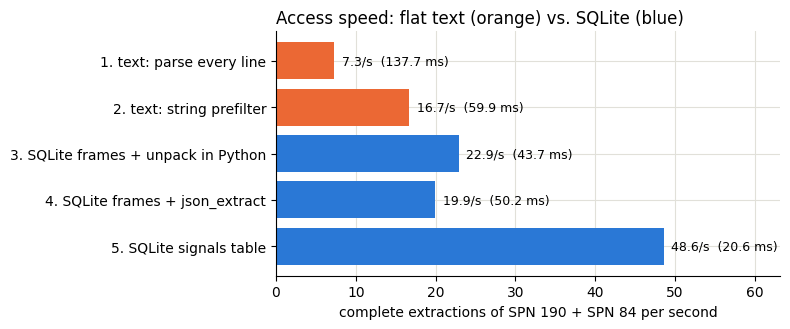

In [22]:
names, rates, mss = [s[0] for s in speed], [s[3] for s in speed], [s[2] for s in speed]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(range(len(speed)), rates, color=[ORANGE, ORANGE, BLUE, BLUE, BLUE])
ax.set_yticks(range(len(speed))); ax.set_yticklabels(names); ax.invert_yaxis()
ax.set_xlabel('complete extractions of SPN 190 + SPN 84 per second')
ax.set_title('Access speed: flat text (orange) vs. SQLite (blue)', loc='left')
ax.set_xlim(right=max(rates) * 1.3)
for i, (v, ms) in enumerate(zip(rates, mss)):
    ax.text(v + max(rates) * 0.02, i, f'{v:,.1f}/s  ({ms:.1f} ms)', va='center', fontsize=9)
tidy(ax); plt.tight_layout()

Engine speed is a *bad* case for the database: a third of all frames in this log are EEC1, so even the indexed query hands back 41 000 rows and most of the time goes into building Python lists. The index shines when the answer is small. Engine hours (SPN 247, PGN 65253) is sent every ten seconds or so, 33 frames in this log, yet the text methods still have to read every line to find them.

In [23]:
ID_HOURS = 0x18FEE500

def hours_text_prefilter(path=LOG):
    key, out = f' {ID_HOURS:08X}#', []
    with open(path) as f:
        for line in f:
            if key in line:
                timestamp, channel, can_id, data = parse_candump(line)
                out.append((timestamp, struct.unpack('<I', data[0:4])[0] * 0.05))
    return out

def hours_sqlite(conn=conn):
    return [(t, struct.unpack('<I', d[0:4])[0] * 0.05) for t, d in
            conn.execute("SELECT timestamp, data FROM frames WHERE channel='can1' AND sa=? AND pgn=65253", (ENGINE,))]

assert hours_text_prefilter() == hours_sqlite()
needle = []
for name, fn in [('text: string prefilter', hours_text_prefilter), ('SQLite frames (indexed)', hours_sqlite)]:
    passes, elapsed, per = timed_loop(fn, budget_s=2.0)
    needle.append((name, len(fn()), per * 1e3, passes / elapsed))
print_table(['method', 'rows returned', 'ms per pass', 'passes per second', 'speedup'],
            [(n, r, ms, rate, rate / needle[0][3]) for n, r, ms, rate in needle], floats='{:,.2f}')

method                   rows returned  ms per pass  passes per second  speedup
-----------------------  -------------  -----------  -----------------  -------
text: string prefilter              33        13.68              73.08     1.00
SQLite frames (indexed)             33         0.03          30,289.32   414.45


## Does the index order matter?
The `signals` index is `(sa, spn, timestamp)`. Would `(spn, sa, timestamp)` be faster? For a query that fixes both `sa` and `spn` the two are the same B-tree lookup, just with the key bytes in a different order, so we expect no difference. The order matters when a query fixes only the *leading* column: `WHERE sa = 0` can use `(sa, spn, ...)` but not `(spn, sa, ...)`, and `WHERE spn = 190` the other way round. Let's check rather than assert. `EXPLAIN QUERY PLAN` says which index SQLite chose; the timed loop says what it cost.

In [24]:
conn.execute('CREATE INDEX IF NOT EXISTS idx_signals_spn_first ON signals (spn, sa, timestamp)')
conn.commit()

queries = {
    'sa and spn fixed': 'SELECT timestamp, value FROM signals WHERE sa=0 AND spn=190',
    'only sa fixed':    'SELECT spn, timestamp, value FROM signals WHERE sa=0',
    'only spn fixed':   'SELECT sa, timestamp, value FROM signals WHERE spn=190',
}
for order, hint in [('(sa, spn, timestamp)', 'idx_signals'), ('(spn, sa, timestamp)', 'idx_signals_spn_first')]:
    print(f'--- index {order} ---')
    for label, q in queries.items():
        q_hinted = q.replace('FROM signals', f'FROM signals INDEXED BY {hint}')   # force the choice so we can time each
        plan = conn.execute('EXPLAIN QUERY PLAN ' + q_hinted).fetchall()[0][3]
        passes, elapsed, per = timed_loop(lambda: conn.execute(q_hinted).fetchall(), budget_s=1.0)
        print(f'{label:18s} {per*1e3:7.2f} ms/pass   {plan}')
conn.execute('DROP INDEX idx_signals_spn_first')
conn.commit()

--- index (sa, spn, timestamp) ---


sa and spn fixed     18.61 ms/pass   SEARCH signals USING INDEX idx_signals (sa=? AND spn=?)


only sa fixed        38.38 ms/pass   SEARCH signals USING INDEX idx_signals (sa=?)


only spn fixed       20.05 ms/pass   SCAN signals USING INDEX idx_signals
--- index (spn, sa, timestamp) ---


sa and spn fixed     19.23 ms/pass   SEARCH signals USING INDEX idx_signals_spn_first (spn=? AND sa=?)


only sa fixed        40.13 ms/pass   SCAN signals USING INDEX idx_signals_spn_first


only spn fixed       20.23 ms/pass   SEARCH signals USING INDEX idx_signals_spn_first (spn=?)


The measurement confirms the reasoning: with both columns fixed the two orders are indistinguishable, and each order can only `SEARCH` for the one-column query that starts with its leading column; the other becomes a `SCAN`. On this small table the scan is still quick, because the index *covers* the query (every column it needs is in the index) and there are only sixty thousand rows to walk; on the 2 GB log the gap between `SEARCH` and `SCAN` is the gap between milliseconds and minutes. So the choice comes down to which single-column question you are more likely to ask. "Everything from the engine" (`sa = 0`) is a common question on a vehicle network, where the source addresses are fixed and few, which is why `(sa, spn, timestamp)` is the order used here. If your queries were "SPN 190 from every ECU that reports it" across a fleet, you would lead with `spn`. A phone book sorted by last name is neither right nor wrong; it depends on what you look people up by.

## When does building the database pay for itself?

In [25]:
meta = dict(conn.execute('SELECT key, value FROM meta'))
build_s = float(meta['load_s']) + float(meta['index_s'])
per_text = speed[0][2] / 1e3                     # method 1, seconds per pass
per_db = speed[2][2] / 1e3                       # method 3
print(f'building the database took {build_s:.1f} s (including every SPN decoded to JSON)')
print(f'one text extraction takes {per_text*1e3:.0f} ms; one indexed SQLite extraction takes {per_db*1e3:.1f} ms')
print(f'break-even after about {build_s / (per_text - per_db):.0f} extractions -- every plot, every SPN, every re-run counts')

building the database took 1.6 s (including every SPN decoded to JSON)
one text extraction takes 138 ms; one indexed SQLite extraction takes 43.7 ms
break-even after about 17 extractions -- every plot, every SPN, every re-run counts


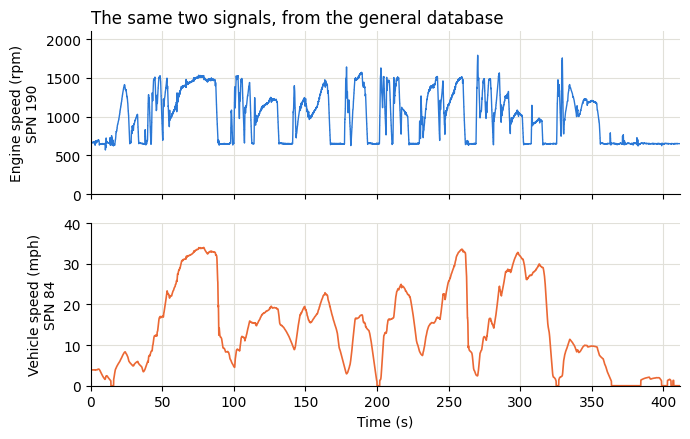

In [26]:
plot_two_signals(conn, title='The same two signals, from the general database')

## Discussion
The string prefilter (method 2) is worth remembering: skipping the parse for lines you do not want gives a real speedup for nothing, and it is how tools like `grep` stay fast. But it still reads the whole file, so its cost grows with the size of the *file*, while the indexed SQLite methods grow with the size of the *answer*. On this seven-minute log the answer for engine speed is 33% of the rows; for engine hours it is 0.02%, and there the index wins by two orders of magnitude.

The `signals` table is fastest because SQLite hands back exactly the two columns we want with no decoding at all. Its weakness is that you have to know which SPNs you want when you build it. The `spns` JSON column is the compromise: every decodable SPN is available without rebuilding, at the cost of parsing JSON per row.

Two more things a database gives you that a text file does not: several log files can be loaded into one database (add a `file` column) and queried together, and SQL aggregates (`GROUP BY sa, pgn`, `MAX(value)`, `AVG(value)`) answer questions about the whole log without writing a loop.

### Exercise
1. Method 4 asks SQLite to parse JSON for every row. Add a generated column, `ALTER TABLE frames ADD COLUMN spn190 REAL AS (json_extract(spns, '$.190'))`, index it, and time it. Is it as fast as the `signals` table?
2. Load `candump_kw_drive.txt` and `candump-2021-10-14_234124.log` into one database with a `file` column. Which source addresses appear in one vehicle and not the other?
3. Repeat the access-speed benchmark on the 2 GB log after building its database with `build_log_database`. How does the ratio between text and SQLite change, and why?

# Large File Analysis
## The data set
The file `2014_KW_T270_cross_country_can_log.txt` is a candump log from a 2014 Kenworth T270 on a cross-country trip, about **2 GB of text**. It can be downloaded from

https://systemscyber.engr.colostate.edu/cybersystems/data/HeavyVehicleCANData/2014_Kenworth_T270/2014_KW_T270_cross_country_can_log.zip

and unzipped into this folder (it is in `.gitignore`). A file of this size changes how you have to work:

* `f.readlines()` would need several gigabytes of RAM for the list of strings alone. Everything below **streams** the file one line at a time and keeps only counters and downsampled summaries in memory.
* One pass at a few hundred thousand lines per second takes a few minutes. That is fine once, not fine every time you re-run a cell. The analysis therefore makes **one pass** that collects everything we will need and caches the result beside the file (`*.features.json` and three small CSV files). Re-running the notebook reads the cache in milliseconds.
* Lifetime counters (odometer, total fuel, engine hours) are read from the first and last messages; per-second **means** are kept for the dynamic signals; GPS fixes are kept in full because there are only a few per minute.

canarchy has a useful habit for files like this: before any heavy pass, look at the first and last 64 kB and *estimate*. We start there.

In [27]:
BIG_FILE = '2014_KW_T270_cross_country_can_log.txt'
if not os.path.exists(BIG_FILE):
    print(f'{BIG_FILE} not found in {os.getcwd()}; falling back to candump_kw_drive.txt so the cells below still run.')
    BIG_FILE = LOG

def utc(t):
    '''Unix seconds -> 'YYYY-MM-DD HH:MM:SS' in UTC.'''
    return time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(t))

def peek(path, chunk=65536):
    '''Get oriented in a huge candump file in milliseconds: read the head and the tail, estimate the rest.'''
    size = os.path.getsize(path)
    with open(path, 'rb') as f:
        head = f.read(chunk).decode(errors='replace').splitlines()
        f.seek(max(0, size - chunk))
        tail = f.read().decode(errors='replace').splitlines()
    good_head = [l for l in head[:-1] if l.startswith('(')]      # the last head line and first tail line may be cut
    good_tail = [l for l in tail[1:] if l.startswith('(')]
    avg_line = sum(len(l) + 1 for l in good_head) / len(good_head)
    t_first, t_last = parse_candump(good_head[0])[0], parse_candump(good_tail[-1])[0]
    return {'size_GB': round(size / 1e9, 3), 'estimated_lines': int(size / avg_line), 'avg_line_bytes': round(avg_line, 1),
            'first_line': good_head[0], 'last_line': good_tail[-1], 'start_utc': utc(t_first), 'end_utc': utc(t_last),
            'span_hours': round((t_last - t_first) / 3600, 2), 'scan_mode': 'estimated from head and tail'}

for k, v in peek(BIG_FILE).items():
    print(f'{k:16s} {v}')

2014_KW_T270_cross_country_can_log.txt not found in /home/claude/work/nb2; falling back to candump_kw_drive.txt so the cells below still run.
size_GB          0.007
estimated_lines  140015
avg_line_bytes   51.0
first_line       (1604007042.461135) can1 18FEBF0B#80067D7D79777B79
last_line        (1604007454.005724) can1 0CF00400#407D84521400F0FF
start_utc        2020-10-29 21:30:42
end_utc          2020-10-29 21:37:34
span_hours       0.11
scan_mode        estimated from head and tail


## What one pass collects
| Feature | How |
|---|---|
| size, lines, frames, unparsable lines, first/last timestamp, duration | counters |
| per-channel, per-ID, per-source-address, per-PGN counts, DLC histogram | `collections.Counter` |
| frames per second (bus load) and gaps longer than a threshold (logging segments) | a counter keyed by `int(timestamp)` |
| per-second means of engine speed, vehicle speed, pedal, load, odometer, fuel, temperatures, voltage | decode only the PGNs that carry them, with plans from the Digital Annex database |
| GPS track from Vehicle Position (PGN 65267, SPNs 584/585) | decode, sanity-check, keep |
| the vehicle's own clock (Time/Date, PGN 65254) compared with the logger's timestamps | decode |
| VIN, Component ID and Software ID (multi-frame BAM messages) | a minimal J1939-21 transport-protocol reassembler |

The BAM reassembler is the one piece not seen in this notebook so far; multi-frame messages are covered fully in *05_J1939/04_Parse_J1939_Multi_Frame_Messages*. In short: a TP.CM frame (PGN 60416) with control byte 32 announces "here come N packets totalling M bytes of PGN X", then N TP.DT frames (PGN 60160) each carry a sequence number and seven bytes.

In [28]:
TP_CM, TP_DT = 60416, 60160                     # J1939-21 transport protocol: connection management, data transfer
ASCII_PGNS = {65260: 'VIN', 65259: 'Component ID', 65242: 'Software ID', 64965: 'ECU ID'}

class BAMReassembler:
    '''Minimal J1939-21 Broadcast Announce Message reassembly. Feed it every TP.CM and TP.DT frame;
    completed messages appear in .messages as (timestamp, sa, pgn, bytes).'''
    def __init__(self):
        self.sessions = {}        # sa -> [target pgn, total bytes, packet count, buffer, packets received]
        self.messages = []

    def feed(self, t, pgn, sa, data):
        if pgn == TP_CM and len(data) >= 8 and data[0] == 32:                 # 32 = BAM control byte
            total = data[1] | (data[2] << 8)
            packets = data[3]
            target_pgn = data[5] | (data[6] << 8) | (data[7] << 16)
            self.sessions[sa] = [target_pgn, total, packets, bytearray(), 0]
        elif pgn == TP_DT and sa in self.sessions and len(data) >= 2:
            s = self.sessions[sa]
            s[3].extend(data[1:8])                                             # byte 0 is the sequence number
            s[4] += 1
            if s[4] >= s[2]:
                self.messages.append((t, sa, s[0], bytes(s[3][:s[1]])))
                del self.sessions[sa]

# Quick self-test with the VIN broadcast pattern: one CM frame, then three DT frames
bam = BAMReassembler()
bam.feed(0.0, TP_CM, 0, bytes([32, 17, 0, 3, 0xFF, 0xEC, 0xFE, 0x00]))       # 17 bytes of PGN 0x00FEEC (65260) in 3 packets
bam.feed(0.1, TP_DT, 0, bytes([1]) + b'1XKAAP8')
bam.feed(0.2, TP_DT, 0, bytes([2]) + b'X4CJ293')
bam.feed(0.3, TP_DT, 0, bytes([3]) + b'142*\xff\xff\xff')
bam.messages

[(0.3, 0, 65260, b'1XKAAP8X4CJ293142')]

In [29]:
def haversine_km(lat1, lon1, lat2, lon2):
    '''Great-circle distance between two points, in km.'''
    R = 6371.0088
    p1, p2 = math.radians(lat1), math.radians(lat2)
    a = math.sin((p2 - p1) / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(math.radians(lon2 - lon1) / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

def write_csv(path, headers, rows):
    with open(path, 'w', newline='') as f:
        w = csv.writer(f); w.writerow(headers); w.writerows(rows)

def read_csv(path):
    '''CSV -> {column: list of floats (None for blanks)}'''
    with open(path, newline='') as f:
        r = csv.reader(f); headers = next(r)
        cols = {h: [] for h in headers}
        for row in r:
            for h, v in zip(headers, row):
                cols[h].append(float(v) if v != '' else None)
    return cols

SIGNAL_SPNS = (190, 84, 91, 92, 245, 250, 247, 110, 175, 171, 108, 168, 183, 96)   # kept as per-second means
GPS_PGN, TIMEDATE_PGN = 65267, 65254

In [30]:
def analyze_big_log(path, dadb, signals=SIGNAL_SPNS, gap_seconds=60.0, progress_every=2_000_000, use_cache=True):
    '''One streaming pass over a candump file. Returns a dict of features and writes them beside the file.'''
    base = os.path.splitext(path)[0]
    out_json = base + '.features.json'
    if use_cache and os.path.exists(out_json) and os.path.getmtime(out_json) > os.path.getmtime(path):
        print('loaded cached results from', out_json)
        return json.load(open(out_json))

    signals = set(signals)
    # Which PGNs carry a signal we keep? Ask the Digital Annex once, then cache plans per PGN.
    wanted = {r[0] for spn in signals for r in dadb.execute('SELECT pgn FROM spn_pgn WHERE spn=?', (spn,))} | {GPS_PGN, TIMEDATE_PGN}
    plans = {pgn: decode_plan(dadb, pgn) for pgn in wanted}
    sa_names = dict(dadb.execute('SELECT sa, name FROM source_addresses'))
    pgn_names = {pgn: (acr, lab) for pgn, acr, lab in dadb.execute('SELECT pgn, acronym, label FROM pgns')}

    id_cache = {}
    chan_count, id_count, sa_count, pgn_count, dlc_count = Counter(), Counter(), Counter(), Counter(), Counter()
    per_second = Counter()                                       # int(t) -> frames: the bus-load timeline
    sig_sum, sig_n = defaultdict(Counter), defaultdict(Counter)  # spn -> {second: sum}, spn -> {second: count}
    gps, timedate, gaps = [], [], []
    n_timedate, timedate_sample = 0, None
    bam = BAMReassembler()
    n_lines = n_frames = n_bad = 0
    t_first = t_last = t_prev = None
    size, t0 = os.path.getsize(path), time.perf_counter()

    with open(path, errors='replace') as f:
        for line in f:
            n_lines += 1
            parts = line.split()
            try:
                t = float(parts[0][1:-1]); channel = parts[1]
                id_text, _, data_text = parts[2].partition('#')
                info = id_cache.get(id_text)
                if info is None:
                    can_id = int(id_text, 16)
                    _, pgn, da, sa = get_j1939_from_id(can_id)
                    info = id_cache[id_text] = (sa, pgn, plans.get(pgn), pgn in (TP_CM, TP_DT))
            except (IndexError, ValueError):
                n_bad += 1; continue
            sa, pgn, plan, is_tp = info
            n_frames += 1
            chan_count[channel] += 1; id_count[id_text] += 1; sa_count[sa] += 1; pgn_count[pgn] += 1; dlc_count[len(data_text) // 2] += 1
            sec = int(t); per_second[sec] += 1
            if t_first is None: t_first = t
            if t_prev is not None and t - t_prev > gap_seconds: gaps.append((t - t_prev, t_prev, t))
            t_prev = t_last = t

            if plan or is_tp:                                    # decode only what we asked for
                data = bytes.fromhex(data_text)
                if is_tp:
                    bam.feed(t, pgn, sa, data); continue
                vals = decode_spns(data, plan)
                if pgn == GPS_PGN:
                    lat, lon = vals.get(584), vals.get(585)
                    if lat is not None and lon is not None and -90 <= lat <= 90 and -180 <= lon <= 180:
                        gps.append((t, lat, lon))
                elif pgn == TIMEDATE_PGN:
                    n_timedate += 1
                    s_, m_, h_, mo, d_, y_ = (vals.get(k) for k in (959, 960, 961, 963, 962, 964))
                    if timedate_sample is None: timedate_sample = dict(seconds=s_, minutes=m_, hours=h_, month=mo, day=d_, year=y_)
                    if None not in (s_, m_, h_, mo, d_, y_) and 1 <= mo <= 12 and 1 <= d_ <= 31.75:
                        try: timedate.append((t, calendar.timegm((int(y_), int(mo), int(d_), int(h_), int(m_), int(s_), 0, 0, 0))))
                        except (ValueError, OverflowError): pass
                else:
                    for spn, v in vals.items():
                        if v is not None and spn in signals:
                            sig_sum[spn][sec] += v; sig_n[spn][sec] += 1
            if n_lines % progress_every == 0:
                print(f'\r  {n_lines:>12,d} lines  {100*f.buffer.tell()/size:5.1f}%  {time.perf_counter()-t0:6.0f} s', end='')
    elapsed = time.perf_counter() - t0
    print(f'\r  {n_lines:,} lines in {elapsed:.0f} s ({n_lines/elapsed:,.0f} lines/s)')

    # --- summaries and cache files -----------------------------------------------------------
    starts, ends = [t_first] + [g[2] for g in gaps], [g[1] for g in gaps] + [t_last]
    segments = [{'segment': i + 1, 'start': s, 'end': e, 'duration_s': e - s} for i, (s, e) in enumerate(zip(starts, ends))]
    gps_summary = None
    if gps:
        dist = sum(d for d in (haversine_km(a[1], a[2], b[1], b[2]) for a, b in zip(gps, gps[1:])) if d < 5.0)  # skip jumps between segments
        gps_summary = {'fixes': len(gps), 'start': gps[0][1:], 'end': gps[-1][1:], 'path_km': round(dist, 1),
                       'lat_min': min(g[1] for g in gps), 'lat_max': max(g[1] for g in gps), 'lon_min': min(g[2] for g in gps), 'lon_max': max(g[2] for g in gps)}
        write_csv(base + '.gps.csv', ['timestamp', 'lat', 'lon'], gps)
    secs = sorted({s for spn in sig_sum for s in sig_sum[spn]})
    spn_list = sorted(sig_sum)
    write_csv(base + '.signals.csv', ['second'] + [f'spn{s}' for s in spn_list],
              [[s] + [round(sig_sum[spn][s] / sig_n[spn][s], 4) if sig_n[spn][s] else '' for spn in spn_list] for s in secs])
    write_csv(base + '.busload.csv', ['second', 'frames'], sorted(per_second.items()))
    first_last = {}
    for spn in spn_list:
        ks = sorted(sig_sum[spn])
        first_last[str(spn)] = (sig_sum[spn][ks[0]] / sig_n[spn][ks[0]], sig_sum[spn][ks[-1]] / sig_n[spn][ks[-1]])
    ascii_msgs = {}
    for t, sa, pgn, payload in bam.messages:
        if pgn in ASCII_PGNS:
            ascii_msgs.setdefault(f'{ASCII_PGNS[pgn]} (PGN {pgn}) from SA {sa}', payload.split(b'*')[0].decode('ascii', 'replace').strip())
    clock = None
    if n_timedate:
        clock = {'messages': n_timedate, 'valid': len(timedate), 'sample': timedate_sample}
        if timedate:
            offsets = sorted(v - t for t, v in timedate)
            clock.update(median_offset_s=offsets[len(offsets) // 2], vehicle_time_first=utc(timedate[0][1]), vehicle_time_last=utc(timedate[-1][1]))
    rates = sorted(per_second.values())
    feats = {'file': os.path.abspath(path), 'size_bytes': size, 'lines': n_lines, 'frames': n_frames, 'bad_lines': n_bad, 'parse_seconds': round(elapsed, 1),
             't_first': t_first, 't_last': t_last, 'duration_s': t_last - t_first, 'start_utc': utc(t_first), 'end_utc': utc(t_last),
             'frames_per_s_mean': round(n_frames / (t_last - t_first), 1), 'frames_per_s_median': rates[len(rates) // 2], 'frames_per_s_max': rates[-1],
             'seconds_with_traffic': len(per_second), 'channels': dict(chan_count), 'unique_ids': len(id_count),
             'dlc_histogram': {str(k): v for k, v in sorted(dlc_count.items())}, 'top_ids': id_count.most_common(25),
             'source_addresses': [{'sa': sa, 'name': sa_names.get(sa, 'Unknown'), 'frames': n} for sa, n in sa_count.most_common()],
             'pgns': [{'pgn': pgn, 'hex': f'{pgn:04X}', 'acronym': pgn_names.get(pgn, ('', ''))[0], 'label': pgn_names.get(pgn, ('', ''))[1], 'frames': n} for pgn, n in pgn_count.most_common()],
             'gaps': [{'gap_s': g, 'before': a, 'after': b} for g, a, b in sorted(gaps, reverse=True)[:50]], 'segments': segments,
             'gps': gps_summary, 'gps_csv': base + '.gps.csv' if gps else None, 'signals_csv': base + '.signals.csv', 'bus_load_csv': base + '.busload.csv',
             'signal_first_last': first_last, 'clock': clock, 'ascii_messages': ascii_msgs, 'bam_messages': len(bam.messages),
             'bam_pgns': {str(k): v for k, v in Counter(m[2] for m in bam.messages).most_common()}}
    json.dump(feats, open(out_json, 'w'), indent=1)
    print('wrote', out_json)
    return feats

def print_summary(f):
    print(f"File            : {f['file']}")
    print(f"Size            : {f['size_bytes']/1e9:.3f} GB, {f['lines']:,} lines, {f['frames']:,} frames, {f['bad_lines']:,} unparsable, parsed in {f['parse_seconds']} s")
    print(f"Time span       : {f['start_utc']} -> {f['end_utc']} UTC  ({f['duration_s']/3600:.2f} h wall, {f['seconds_with_traffic']/3600:.2f} h with traffic)")
    print(f"Frame rate      : mean {f['frames_per_s_mean']} /s, median {f['frames_per_s_median']} /s, peak {f['frames_per_s_max']} /s")
    print(f"Channels        : {f['channels']}")
    print(f"Unique IDs      : {f['unique_ids']},  source addresses: {len(f['source_addresses'])},  PGNs: {len(f['pgns'])}")
    print(f"Segments        : {len(f['segments'])} (gaps longer than the threshold: {len(f['gaps'])})")
    if f['gps']:
        print(f"GPS             : {f['gps']['fixes']:,} fixes, {f['gps']['path_km']:,} km of path, from {f['gps']['start']} to {f['gps']['end']}")
    c = f['clock']
    if c and c.get('valid'):
        print(f"Vehicle clock   : {c['vehicle_time_first']} -> {c['vehicle_time_last']} UTC (median offset from the logger {c['median_offset_s']:+.0f} s)")
    elif c:
        print(f"Vehicle clock   : {c['messages']:,} Time/Date messages but none with a valid date, e.g. {c['sample']}")
    for k, v in f['ascii_messages'].items():
        print(f'{k:32s}: {v}')
    for spn, name in (('245', 'Odometer (km)'), ('250', 'Total fuel (L)'), ('247', 'Engine hours')):
        fl = f['signal_first_last'].get(spn)
        if fl:
            print(f'{name:16s}: {fl[0]:,.1f} -> {fl[1]:,.1f}  (change {fl[1]-fl[0]:,.1f})')

In [31]:
feats = analyze_big_log(BIG_FILE, dadb)
print_summary(feats)


  137,309 lines in 0 s (374,912 lines/s)


wrote candump_kw_drive.features.json
File            : /home/claude/work/nb2/candump_kw_drive.txt
Size            : 0.007 GB, 137,309 lines, 137,309 frames, 0 unparsable, parsed in 0.4 s
Time span       : 2020-10-29 21:30:42 -> 2020-10-29 21:37:34 UTC  (0.11 h wall, 0.11 h with traffic)
Frame rate      : mean 333.6 /s, median 332 /s, peak 477 /s
Channels        : {'can1': 137309}
Unique IDs      : 55,  source addresses: 5,  PGNs: 41
Segments        : 1 (gaps longer than the threshold: 0)
Vehicle clock   : 412 Time/Date messages but none with a valid date, e.g. {'seconds': 34.0, 'minutes': 5.0, 'hours': 1.0, 'month': 0.0, 'day': 8.0, 'year': 2007.0}
VIN (PGN 65260) from SA 0       : 1XKAAP8X4CJ293142
Odometer (km)   : 774,888.0 -> 774,890.6  (change 2.6)
Total fuel (L)  : 256,087.5 -> 256,088.5  (change 1.0)
Engine hours    : 9,793.4 -> 9,793.6  (change 0.2)


## Metadata
The summary above is the "spec sheet" of the log. The VIN comes straight off the bus (PGN 65260 is broadcast on request and at power-up), a useful reminder that a CAN log identifies the vehicle it came from. Below: the talkers on the network, and the most frequent parameter groups, all named through the Digital Annex database.

In [32]:
total = sum(s['frames'] for s in feats['source_addresses'])
print_table(['SA', 'name', 'frames', 'share'], [(s['sa'], s['name'], s['frames'], f"{100*s['frames']/total:.1f}%") for s in feats['source_addresses']])
print()
print_table(['PGN', 'hex', 'acronym', 'label', 'frames', 'share'],
            [(p['pgn'], p['hex'], p['acronym'], p['label'], p['frames'], f"{100*p['frames']/total:.2f}%") for p in feats['pgns']], max_rows=20)

SA  name                                  frames  share
--  ------------------------------------  ------  -----
 0  Engine #1                              70296  51.2%
11  Brakes - System Controller             33168  24.2%
49  Cab Controller - Primary               28574  20.8%
15  Retarder - Engine                       4448  3.2% 
85  Diesel Particulate Filter Controller     823  0.6% 

PGN    hex   acronym  label                                                       frames  share 
-----  ----  -------  ----------------------------------------------------------  ------  ------
61444  F004  EEC1     Electronic Engine Controller 1                               41156  29.97%
65134  FE6E  HRW      High Resolution Wheel Speed                                  20436  14.88%
61443  F003  EEC2     Electronic Engine Controller 2                               16462  11.99%
65265  FEF1  CCVS1    Cruise Control/Vehicle Speed 1                                8232  6.00% 
65266  FEF2  LFE1     Fue

## Bus load and logging segments
Frames per second over the whole log shows when the logger was running, when the vehicle was on, and whether the bus load was constant. Long silences split the log into **segments**: separate drives, or the logger being unplugged. A cross-country trip is several days of driving, so expect one segment per drive.

segment  start (UTC)          end (UTC)            duration (h)
-------  -------------------  -------------------  ------------
      1  2020-10-29 21:30:42  2020-10-29 21:37:34          0.11


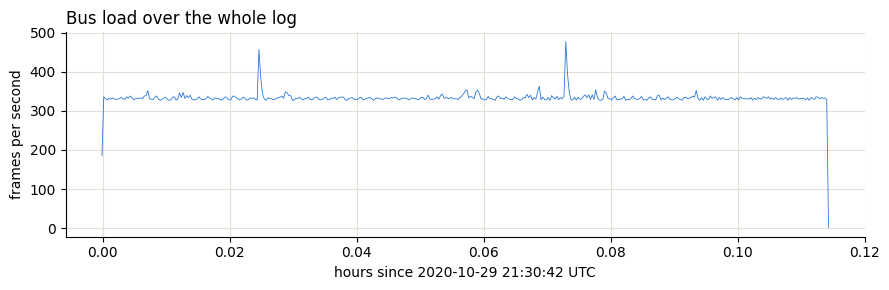

In [33]:
load = read_csv(feats['bus_load_csv'])
t_start = feats['t_first']
hours = [(s - t_start) / 3600 for s in load['second']]
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(hours, load['frames'], color=BLUE, linewidth=0.6)
ax.set_ylabel('frames per second'); ax.set_xlabel(f"hours since {feats['start_utc']} UTC")
ax.set_title('Bus load over the whole log', loc='left'); tidy(ax); plt.tight_layout()

print_table(['segment', 'start (UTC)', 'end (UTC)', 'duration (h)'],
            [(s['segment'], utc(s['start']), utc(s['end']), s['duration_s'] / 3600) for s in feats['segments']], floats='{:.2f}')

## Trip features from the signals
The per-second means give a compact picture of the whole trip. Odometer, total fuel and engine hours are lifetime counters, so their change from first to last message is the distance driven, fuel burned and engine time for this log, from which fuel economy follows.

In [34]:
sig = read_csv(feats['signals_csv'])
sig_hours = [(s - sig['second'][0]) / 3600 for s in sig['second']]

def first_last_change(col):
    vals = [v for v in sig.get(col, []) if v is not None]
    return vals[-1] - vals[0] if vals else None

dkm, dl, dh = first_last_change('spn245'), first_last_change('spn250'), first_last_change('spn247')
speeds = sig.get('spn84', []); rpms = sig.get('spn190', [])
moving = [v is not None and v > 1 for v in speeds]                       # km/h
running = [v is not None and v > 300 for v in rpms]
summary = [
    ('distance (km)', dkm), ('distance (mi)', dkm * 0.621371 if dkm else None),
    ('fuel used (L)', dl), ('fuel used (gal)', dl / 3.78541 if dl else None), ('engine hours', dh),
    ('fuel economy (L/100 km)', 100 * dl / dkm if dkm else None),
    ('fuel economy (mpg)', (dkm * 0.621371) / (dl / 3.78541) if dl else None),
    ('average speed while moving (mph)', 0.621371 * sum(v for v, m in zip(speeds, moving) if m) / max(1, sum(moving)) if speeds else None),
    ('top speed, 1-s mean (mph)', 0.621371 * max(v for v in speeds if v is not None) if speeds else None),
    ('time with engine running (h)', sum(running) / 3600 if rpms else None),
    ('time idling, engine on and stopped (h)', sum(r and not m for r, m in zip(running, moving)) / 3600 if rpms and speeds else None),
]
print_table(['trip feature', 'value'], summary, floats='{:,.2f}')

trip feature                            value
--------------------------------------  -----
distance (km)                            2.62
distance (mi)                            1.63
fuel used (L)                            1.00
fuel used (gal)                          0.26
engine hours                             0.15
fuel economy (L/100 km)                 38.10
fuel economy (mpg)                       6.17
average speed while moving (mph)        15.13
top speed, 1-s mean (mph)               33.86
time with engine running (h)             0.11
time idling, engine on and stopped (h)   0.01


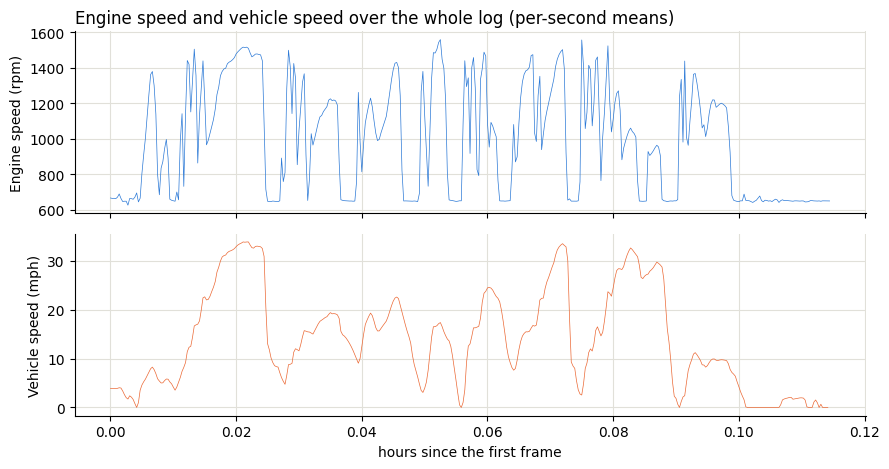

In [35]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 4.8))
ax1.plot(sig_hours, rpms, color=BLUE, linewidth=0.5); ax1.set_ylabel('Engine speed (rpm)')
ax2.plot(sig_hours, [v * 0.621371 if v is not None else None for v in speeds], color=ORANGE, linewidth=0.5)
ax2.set_ylabel('Vehicle speed (mph)'); ax2.set_xlabel('hours since the first frame')
ax1.set_title('Engine speed and vehicle speed over the whole log (per-second means)', loc='left'); tidy(ax1); tidy(ax2); plt.tight_layout()

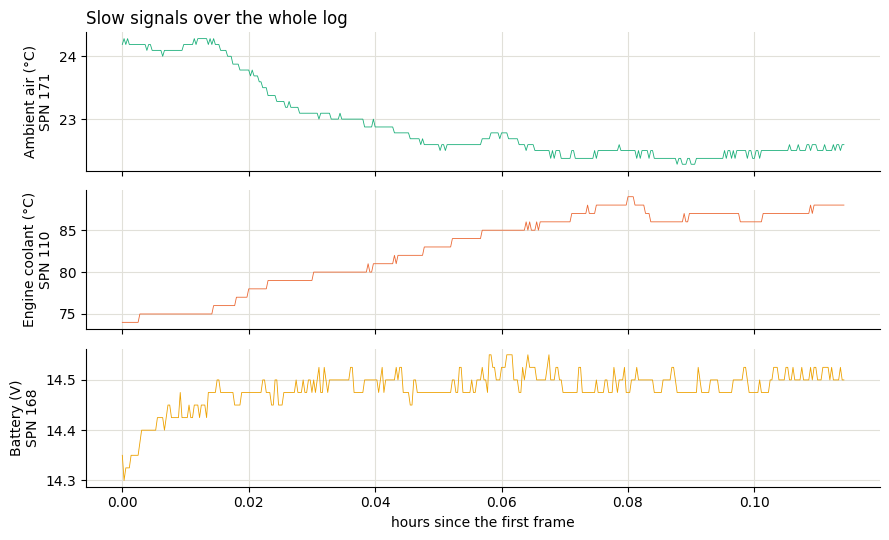

In [36]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 5.5))
for ax, col, label, color in zip(axes, ['spn171', 'spn110', 'spn168'],
                                 ['Ambient air (°C)\nSPN 171', 'Engine coolant (°C)\nSPN 110', 'Battery (V)\nSPN 168'], [AQUA, ORANGE, YELLOW]):
    if col in sig:
        ax.plot(sig_hours, sig[col], color=color, linewidth=0.6)
    ax.set_ylabel(label); tidy(ax)
axes[-1].set_xlabel('hours since the first frame'); axes[0].set_title('Slow signals over the whole log', loc='left'); plt.tight_layout()

## Where did it go? A map from the GPS messages
Vehicle Position (PGN 65267, 0xFEF3) carries latitude in bytes 1-4 and longitude in bytes 5-8, each a 32-bit value with a resolution of 10⁻⁷ degree and an offset of -210 degrees (the Digital Annex rows for SPNs 584 and 585). Not every truck broadcasts it; it usually comes from a telematics unit or the cab controller. If the log has it, the fixes plot directly as a track. The path length is the sum of great-circle distances between consecutive fixes (jumps over 5 km, gaps between segments or bad fixes, are skipped) and can be checked against the odometer.

The plot below is a plain longitude/latitude drawing with the aspect ratio corrected for the latitude, which is enough to recognize a route. For a map with streets behind it, the `folium` package (`pip install folium`) will draw the same `lat`/`lon` lists on OpenStreetMap tiles in about six lines.

In [37]:
if feats['gps']:
    gps = read_csv(feats['gps_csv'])
    print(f"{len(gps['lat']):,} fixes; path length {feats['gps']['path_km']:,} km" + (f" vs. odometer change {dkm:,.1f} km" if dkm else ''))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(gps['lon'], gps['lat'], color=BLUE, linewidth=1.2)
    ax.scatter(gps['lon'][0], gps['lat'][0], color=AQUA, s=60, zorder=3, label='start')
    ax.scatter(gps['lon'][-1], gps['lat'][-1], color=ORANGE, s=60, zorder=3, label='end')
    mean_lat = sum(gps['lat']) / len(gps['lat'])
    ax.set_aspect(1 / math.cos(math.radians(mean_lat)))                # keep east-west and north-south distances honest
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude'); ax.set_title('GPS track from PGN 65267', loc='left')
    ax.margins(0.08); tidy(ax); ax.legend(frameon=False, loc='best'); plt.tight_layout()

    # where and when did each segment start and end?
    def fix_near(t):
        i = min(range(len(gps['timestamp'])), key=lambda k: abs(gps['timestamp'][k] - t))
        return f"{gps['lat'][i]:.4f}, {gps['lon'][i]:.4f}" if abs(gps['timestamp'][i] - t) < 300 else 'no fix'
    print_table(['segment', 'start (UTC)', 'end (UTC)', 'duration (h)', 'start position', 'end position'],
                [(s['segment'], utc(s['start']), utc(s['end']), s['duration_s'] / 3600, fix_near(s['start']), fix_near(s['end'])) for s in feats['segments']], floats='{:.2f}')
else:
    print('No Vehicle Position (PGN 65267) messages in this log, so there is no track to draw.')

No Vehicle Position (PGN 65267) messages in this log, so there is no track to draw.


## Checking the logger's clock against the vehicle's
The timestamps in a candump file come from the logging computer's clock. A Raspberry Pi without a real-time clock or a network connection starts at whatever time it last knew, so the timestamps can be off by hours or years even though the intervals between frames are right. The vehicle broadcasts its own Time/Date (PGN 65254, 0xFEE6); comparing the two is a cheap integrity check on the evidence.

In [38]:
c = feats['clock']
if c and c.get('valid'):
    print(f"{c['valid']:,} valid Time/Date messages of {c['messages']:,}; vehicle clock {c['vehicle_time_first']} -> {c['vehicle_time_last']} UTC")
    print(f"logger timestamps {feats['start_utc']} -> {feats['end_utc']} UTC")
    off = c['median_offset_s']
    print(f"median (vehicle - logger) = {off:+.0f} s = {off/3600:+.2f} h" + ('  (consistent with a time-zone or DST difference)' if abs(off) >= 3000 and min(abs(off) % 3600, 3600 - abs(off) % 3600) < 120 else ''))
elif c:
    print(f"{c['messages']:,} Time/Date messages, none with a valid date. Example decode: {c['sample']}")
    print('A month of 0 and a year of 2007 mean the ECU that sends Time/Date has never had its clock set;')
    print('the logger timestamps are the only usable time reference in this log.')
else:
    print('No Time/Date (PGN 65254) messages in this log.')

412 Time/Date messages, none with a valid date. Example decode: {'seconds': 34.0, 'minutes': 5.0, 'hours': 1.0, 'month': 0.0, 'day': 8.0, 'year': 2007.0}
A month of 0 and a year of 2007 mean the ECU that sends Time/Date has never had its clock set;
the logger timestamps are the only usable time reference in this log.


## Summary of the large-file analysis
Streaming the file once turned two gigabytes of text into a page of facts: the vehicle (from its VIN), the ECUs on the network and how much each talks, when the logger ran, how far the truck went and how much fuel it burned, what the weather was like, and where it was. None of that needed more than a few hundred megabytes of memory, and all of it is cached so the plots above re-run instantly.

### Exercise
1. The frames-per-second plot has a characteristic level while the engine is running. What is the utilisation of a 250 kbit/s bus at that level, using 130 bits per frame?
2. From the per-second vehicle speed, how many minutes were spent above 70 mph? Use the GPS track to guess which states those were in.
3. Fault codes: DM1 (PGN 65226) is broadcast when a lamp is on. Extend the single pass to count DM1 frames per hour and find the first time a fault appeared. (The DTC layout is in J1939-73: SPN in the low 19 bits, FMI in the next 5, occurrence count in the last byte.)
4. Borrow an idea from canarchy: compute the median and MAD of the inter-frame gap for each CAN ID over the first segment, then flag seconds in the rest of the log where an ID's timing departs by more than five scaled MADs. What do the flagged seconds have in common?

# Summary
* Open-source tools already cover much of the J1939 workflow: pretty_j1939 for decoding, canarchy for reverse engineering and anomaly detection, TruckDevil for active assessment, the TruckHacking hardware for the other truck networks, CAN Logger 3 for logs that can be trusted as evidence, and the Linux `can-j1939` stack for building applications. Knowing what each is good for saves reinventing it; building small versions by hand, as we did here, is how you learn to read them.
* Parsing a log **once** into SQLite, with the J1939 keys as indexed columns, turns every later question into a query. The index order should follow the questions you ask most; for one vehicle, lead with the source address.
* The Digital Annex becomes a database in a few dozen lines once its columns are understood, and then a general decoder is four numbers per SPN plus the indicator rules for "not available" and "error".
* Files too big to fit in memory are streamed once, with everything you might want collected in a single pass and cached; the head and tail of the file tell you what to expect before you start.
* None of this needed more than the standard library, `openpyxl` and `matplotlib`. Libraries like pandas make some of these steps shorter, but every step is a loop, a dictionary or a query, and knowing that is what lets you debug the tool when it misbehaves.